# Word Embedding Pipeline for LSH + Topic Modeling

This notebook builds word-level embeddings from `md_summary_en_512` summaries for downstream LSH clustering and topic modeling.

**Outputs (saved under `d:/MFIN/7036`)**
- `embedding_word_to_vec.pkl` (dict: word -> vector)
- `embedding_matrix_bundle.pkl` (matrix + vocab + metadata)

In [6]:
# If needed, uncomment and run once:
# %pip install gensim scikit-learn pandas tqdm

from pathlib import Path
import re
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

BASE_DIR = Path(r"d:/MFIN/7036")
INPUT_DIR = BASE_DIR / "md_summary_en_512"

WORD_VEC_PKL = BASE_DIR / "embedding_word_to_vec.pkl"
MATRIX_BUNDLE_PKL = BASE_DIR / "embedding_matrix_bundle.pkl"

MODEL_NAME = "word2vec"
TARGET_DIM = 300   # Word2Vec vector size
MIN_WORD_LEN = 3
MIN_FREQ = 2

W2V_WINDOW = 8
W2V_SG = 1
W2V_EPOCHS = 20
W2V_WORKERS = 4
W2V_NEGATIVE = 10

print("Input dir:", INPUT_DIR)
print("Model:", MODEL_NAME)
print("Vector size:", TARGET_DIM)
print("Word2Vec config:", {
    "window": W2V_WINDOW,
    "sg": W2V_SG,
    "epochs": W2V_EPOCHS,
    "workers": W2V_WORKERS,
    "negative": W2V_NEGATIVE,
    "min_count": MIN_FREQ,
})

Input dir: d:\MFIN\7036\md_summary_en_512
Model: word2vec
Vector size: 300
Word2Vec config: {'window': 8, 'sg': 1, 'epochs': 20, 'workers': 4, 'negative': 10, 'min_count': 2}


### Step 1: custom_stopwords = {

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

In [7]:
custom_stopwords = {
    "company", "report", "analyst", "research", "market",
    "quarter", "year", "group", "business", "industry",
    "china", "chinese", "stock", "securities"
}
STOPWORDS = set(ENGLISH_STOP_WORDS).union(custom_stopwords)

token_pattern = re.compile(r"[a-zA-Z][a-zA-Z0-9_-]*")

def preprocess_text_to_tokens(text: str):
    text = str(text).lower()
    tokens = token_pattern.findall(text)
    clean = [
        t for t in tokens
        if t not in STOPWORDS and len(t) >= MIN_WORD_LEN and not t.isdigit()
    ]
    return clean

txt_files = sorted(INPUT_DIR.rglob("*.txt"))
if not txt_files:
    raise FileNotFoundError(f"No .txt files found under: {INPUT_DIR}")

doc_tokens = {}
all_tokens = []

for fp in tqdm(txt_files, desc="Preprocessing summaries"):
    text = fp.read_text(encoding="utf-8", errors="ignore")
    tokens = preprocess_text_to_tokens(text)
    doc_tokens[str(fp)] = tokens
    all_tokens.extend(tokens)

freq = pd.Series(all_tokens).value_counts()
vocab = freq[freq >= MIN_FREQ].index.tolist()

print("Documents:", len(txt_files))
print("Total tokens (after cleaning):", len(all_tokens))
print("Vocab size (freq >= MIN_FREQ):", len(vocab))
print("Top words:", freq.head(15).to_dict())

Preprocessing summaries: 100%|██████████| 41230/41230 [03:06<00:00, 221.13it/s]


Documents: 41230
Total tokens (after cleaning): 5986841
Vocab size (freq >= MIN_FREQ): 16833
Top words: {'billion': 229152, 'yuan': 175187, 'growth': 120470, 'rmb': 109763, 'net': 107732, 'revenue': 107122, 'profit': 85366, 'risks': 74162, 'expected': 59141, 'financial': 59013, 'yoy': 57544, 'strong': 57233, 'cash': 56558, 'potential': 50350, 'include': 50269}


### Step 2: sentences = [toks for toks in doc_tokens.values() if toks]

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

In [8]:
sentences = [toks for toks in doc_tokens.values() if toks]
if not sentences:
    raise RuntimeError("No tokenized documents available for Word2Vec training")

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=TARGET_DIM,
    window=W2V_WINDOW,
    min_count=MIN_FREQ,
    sg=W2V_SG,
    epochs=W2V_EPOCHS,
    workers=W2V_WORKERS,
    negative=W2V_NEGATIVE,
    seed=42,
    compute_loss=False,
    sorted_vocab=1,
    hs=0,
    sample=1e-4,
    alpha=0.025,
    min_alpha=0.0005,
)

word_to_vec = {}
missing_words = []

for w in tqdm(vocab, desc="Building word vectors (Word2Vec)"):
    if w in w2v_model.wv:
        word_to_vec[w] = w2v_model.wv[w].astype(np.float32)
    else:
        missing_words.append(w)

print("Embedded words:", len(word_to_vec))
print("Missing words:", len(missing_words))
if word_to_vec:
    sample_word = next(iter(word_to_vec.keys()))
    print(f"Example: vector('{sample_word}') shape =", word_to_vec[sample_word].shape)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Embedded words: 16833
Missing words: 0
Example: vector('billion') shape = (300,)


### Step 3: Build matrix for LSH and optional dimensionality reduction

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

In [9]:
# Build matrix for LSH and optional dimensionality reduction
vocab_final = sorted(word_to_vec.keys())
X = np.vstack([word_to_vec[w] for w in vocab_final]).astype(np.float32)

original_dim = X.shape[1]
if TARGET_DIM is not None and TARGET_DIM < original_dim and X.shape[0] > TARGET_DIM:
    pca = PCA(n_components=TARGET_DIM, random_state=42)
    X_reduced = pca.fit_transform(X).astype(np.float32)
    vec_dim = TARGET_DIM
else:
    X_reduced = X
    vec_dim = original_dim

# L2 normalize (recommended for cosine/LSH workflows)
norm = np.linalg.norm(X_reduced, axis=1, keepdims=True) + 1e-12
X_l2 = (X_reduced / norm).astype(np.float32)

word_to_vec_final = {w: X_l2[i] for i, w in enumerate(vocab_final)}

print("Matrix shape:", X_l2.shape)
print("Vector dimension:", vec_dim)
print("Sample words:", vocab_final[:10])

Matrix shape: (16833, 300)
Vector dimension: 300
Sample words: ['a-6', 'a-category', 'a-class', 'a-client', 'a-feng', 'a-h', 'a-round', 'a-series', 'a-share', 'a-shares']


### Step 4: Save artifacts for LSH + topic modeling

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

In [10]:
# Save artifacts for LSH + topic modeling
with open(WORD_VEC_PKL, "wb") as f:
    pickle.dump(word_to_vec_final, f)

bundle = {
    "vocab": vocab_final,
    "matrix": X_l2,
    "word_to_index": {w: i for i, w in enumerate(vocab_final)},
    "doc_tokens": doc_tokens,
    "config": {
        "model_name": MODEL_NAME,
        "target_dim": TARGET_DIM,
        "min_word_len": MIN_WORD_LEN,
        "min_freq": MIN_FREQ,
    }
}

with open(MATRIX_BUNDLE_PKL, "wb") as f:
    pickle.dump(bundle, f)

print("Saved:")
print(" -", WORD_VEC_PKL)
print(" -", MATRIX_BUNDLE_PKL)

Saved:
 - d:\MFIN\7036\embedding_word_to_vec.pkl
 - d:\MFIN\7036\embedding_matrix_bundle.pkl


### Step 5: Demo outputs

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

In [11]:
# Demo outputs
for w in ["mineral", "securities", "growth", "risk"]:
    if w in word_to_vec_final:
        print(f"vector('{w}') =", word_to_vec_final[w][:8], "...")
    else:
        print(f"vector('{w}') not in vocab (filtered or absent).")

vector('mineral') = [-0.09020111 -0.06654253  0.00831462 -0.02530397  0.01755015 -0.00522275
  0.05991847 -0.049592  ] ...
vector('securities') not in vocab (filtered or absent).
vector('growth') = [ 0.00300745 -0.0507145   0.0480219  -0.1344011   0.01737852 -0.03630707
  0.05520374  0.01085104] ...
vector('risk') = [ 0.06039161  0.0348698  -0.06739351 -0.06943639 -0.08042853  0.09330458
 -0.00233835  0.02940333] ...


## Stage I: LSH Clustering + Topic Modeling to Build TFs

Generate text factors from word embeddings:
1) run LSH on word vectors to get word clusters,
2) run per-cluster topic decomposition,
3) save TFs as Stage II input (`Si`, `Fi`, `di`).

In [12]:
from collections import Counter, defaultdict
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

# ---------- Stage I config ----------
# Can use either embedding_word_to_vec.pkl or embedding_matrix_bundle.pkl
STAGE1_USE_BUNDLE = True

# A-mode tuning for more factors (target around 50)
TARGET_FACTOR_COUNT = 50
N_LSH_BITS = 14
MIN_CLUSTER_SIZE = 8
MAX_CLUSTER_SIZE = 500
MIN_DOCS_PER_CLUSTER = 30
RANDOM_STATE = 42

# D-mode filtering for noisy numeric/amount tokens
DROP_NUMERIC_STYLE_TOKENS = True
ENTITY_FILTER_ENABLED = True
ENTITY_FILTER_USE_HS300 = True
ENTITY_FILTER_USE_FOLDER_NAMES = True
ENTITY_FILTER_MANUAL_TXT = BASE_DIR / "entity_stopwords_manual.txt"
ENTITY_FILTER_AUTO_CSV = BASE_DIR / "entity_stopwords_auto.csv"
ENTITY_ORG_SUFFIX = ("inc", "corp", "ltd", "group", "holdings", "bank", "insurance", "pharma", "biotech", "motors", "energy", "mining")
ENTITY_GEO_HINTS = {"city", "province", "county", "district", "river", "bay", "port"}
ENTITY_PRODUCT_HINTS = {"model", "series", "vaccine", "sedan", "suv", "drug"}
ENTITY_WHITELIST = {"cpi", "ppi", "m1", "m2", "gdp", "roe", "roa", "ebit", "eps", "pe", "pb"}

TEXT_FACTORS_PKL = BASE_DIR / "text_factors_stage1.pkl"
TEXT_FACTORS_NPY = BASE_DIR / "text_factors_stage1.npy"
TEXT_FACTORS_CLUSTER_CSV = BASE_DIR / "text_factors_stage1_clusters.csv"

rng = np.random.default_rng(RANDOM_STATE)

ENTITY_STOPWORDS = set()
entity_token_pattern = re.compile(r"[a-zA-Z][a-zA-Z0-9_-]*")


def load_manual_entity_words(path: Path):
    if not path.exists():
        return set()
    words = set()
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        s = line.strip().lower()
        if not s or s.startswith("#"):
            continue
        words.add(s)
    return words


def infer_name_col(df: pd.DataFrame):
    if "股票简称" in df.columns:
        return "股票简称"
    for c in df.columns:
        if ("简称" in str(c)) or ("名称" in str(c)):
            return c
    return None


def build_entity_stopwords(doc_tokens_dict: dict):
    stop = set()

    if ENTITY_FILTER_USE_FOLDER_NAMES:
        for doc_id in doc_tokens_dict.keys():
            p = Path(str(doc_id))
            folder = p.parent.name.lower()
            for tk in entity_token_pattern.findall(folder):
                if len(tk) >= MIN_WORD_LEN:
                    stop.add(tk)

    if ENTITY_FILTER_USE_HS300:
        hs300_candidates = [BASE_DIR / "HS300.csv", BASE_DIR / "old_version" / "HS300.csv"]
        hs300_file = next((p for p in hs300_candidates if p.exists()), None)
        if hs300_file is not None:
            hdf = pd.read_csv(hs300_file, dtype=str)
            name_col = infer_name_col(hdf)
            if name_col is not None:
                for nm in hdf[name_col].fillna("").astype(str).tolist():
                    s = nm.strip().lower()
                    for tk in entity_token_pattern.findall(s):
                        if len(tk) >= MIN_WORD_LEN:
                            stop.add(tk)

    stop.update(load_manual_entity_words(ENTITY_FILTER_MANUAL_TXT))
    stop = {w for w in stop if len(w) >= MIN_WORD_LEN}
    return stop


def is_entity_like_token(s: str) -> bool:
    if not ENTITY_FILTER_ENABLED:
        return False
    if s in ENTITY_WHITELIST:
        return False
    if s in ENTITY_STOPWORDS:
        return True
    if any(s.endswith(x) for x in ENTITY_ORG_SUFFIX):
        return True
    parts = re.split(r"[-_]", s)
    if any(p in ENTITY_GEO_HINTS for p in parts):
        return True
    if any(p in ENTITY_PRODUCT_HINTS for p in parts):
        return True
    return False


def is_noisy_token(w: str) -> bool:
    if not DROP_NUMERIC_STYLE_TOKENS:
        return False
    s = str(w).lower().strip()
    if not s:
        return True
    # currency+digits patterns: rmb120, usd30, cny2000
    if re.match(r"^(rmb|usd|cny|hkd|eur)\d+$", s):
        return True
    # contains long digit runs: 202401, 12345, xx2024yy
    if re.search(r"\d{3,}", s):
        return True
    # mostly non-alpha tokens
    alpha_cnt = sum(ch.isalpha() for ch in s)
    if alpha_cnt == 0:
        return True
    if is_entity_like_token(s):
        return True
    return False


# ---------- Load embeddings + vocab + doc_tokens ----------
if STAGE1_USE_BUNDLE and MATRIX_BUNDLE_PKL.exists():
    with open(MATRIX_BUNDLE_PKL, "rb") as f:
        b = pickle.load(f)
    vocab_stage1_all = list(b["vocab"])
    X_words_all = np.asarray(b["matrix"], dtype=np.float32)
    doc_tokens_stage1 = b.get("doc_tokens", None)
else:
    with open(WORD_VEC_PKL, "rb") as f:
        w2v = pickle.load(f)
    vocab_stage1_all = sorted(w2v.keys())
    X_words_all = np.vstack([w2v[w] for w in vocab_stage1_all]).astype(np.float32)
    doc_tokens_stage1 = None

if doc_tokens_stage1 is None:
    if "doc_tokens" in globals():
        doc_tokens_stage1 = doc_tokens
    else:
        raise RuntimeError(
            "doc_tokens not found. Run preprocessing cell first, or use embedding_matrix_bundle.pkl with doc_tokens included."
        )

if ENTITY_FILTER_ENABLED:
    ENTITY_STOPWORDS = build_entity_stopwords(doc_tokens_stage1)
    pd.DataFrame({"token": sorted(ENTITY_STOPWORDS)}).to_csv(ENTITY_FILTER_AUTO_CSV, index=False, encoding="utf-8-sig")
    print("Entity stopwords built:", len(ENTITY_STOPWORDS))
    print("Entity stopwords file:", ENTITY_FILTER_AUTO_CSV)

# apply D-mode vocabulary filtering
keep_mask = np.array([not is_noisy_token(w) for w in vocab_stage1_all], dtype=bool)
vocab_stage1 = [str(w) for w, k in zip(vocab_stage1_all, keep_mask) if k]
X_words = X_words_all[keep_mask]
entity_removed = [w for w in vocab_stage1_all if is_entity_like_token(str(w).lower().strip())]

word_to_idx_stage1 = {w: i for i, w in enumerate(vocab_stage1)}

print("Stage I vocab size (raw):", len(vocab_stage1_all))
print("Stage I vocab size (filtered):", len(vocab_stage1))
print("Entity-like words removed:", len(entity_removed))
print("Entity-like sample:", sorted({str(w).lower() for w in entity_removed})[:20])
print("Stage I embedding matrix:", X_words.shape)
print("Stage I documents:", len(doc_tokens_stage1))

# ---------- LSH clustering on word embeddings ----------
Xn = normalize(X_words, norm="l2")
planes = rng.standard_normal((N_LSH_BITS, Xn.shape[1]), dtype=np.float32)

bits = (Xn @ planes.T) >= 0
packed = np.packbits(bits.astype(np.uint8), axis=1)
keys = [row.tobytes().hex() for row in packed]

buckets = defaultdict(list)
for i, k in enumerate(keys):
    buckets[k].append(i)


def build_clusters(min_cluster_size: int):
    out = []
    for k, idxs in buckets.items():
        if len(idxs) < min_cluster_size:
            continue
        if len(idxs) > MAX_CLUSTER_SIZE:
            continue
        out.append((k, idxs))
    return out

clusters = build_clusters(MIN_CLUSTER_SIZE)
used_min_cluster_size = MIN_CLUSTER_SIZE

# target-aware relaxation (A-mode): if too few candidate clusters, relax minimum size
if len(clusters) < int(TARGET_FACTOR_COUNT * 0.8):
    for relaxed_min in [6, 5]:
        clusters_try = build_clusters(relaxed_min)
        if len(clusters_try) > len(clusters):
            clusters = clusters_try
            used_min_cluster_size = relaxed_min
        if len(clusters) >= int(TARGET_FACTOR_COUNT * 0.8):
            break

print("Raw LSH buckets:", len(buckets))
print("Candidate clusters:", len(clusters))
print("Used MIN_CLUSTER_SIZE:", used_min_cluster_size)

if not clusters:
    raise RuntimeError("No valid clusters found. Try fewer bits or smaller MIN_CLUSTER_SIZE.")

# ---------- Build inverted index: word -> {doc_idx: tf} ----------
doc_ids_stage1 = sorted(doc_tokens_stage1.keys())
word_doc_counts = defaultdict(dict)

for di, doc_id in enumerate(doc_ids_stage1):
    toks = doc_tokens_stage1[doc_id]
    cnt = Counter(t for t in toks if (t in word_to_idx_stage1 and not is_noisy_token(t)))
    for w, n in cnt.items():
        word_doc_counts[w][di] = int(n)

print("Built inverted index for words in vocabulary:", len(word_doc_counts))

# ---------- Topic modeling per cluster: 1-factor SVD ----------
text_factors = []
cluster_rows = []

for factor_idx, (cluster_key, idxs) in enumerate(clusters, start=1):
    words = [vocab_stage1[i] for i in idxs]

    docs_union = set()
    for w in words:
        docs_union.update(word_doc_counts.get(w, {}).keys())

    if len(docs_union) < MIN_DOCS_PER_CLUSTER:
        continue

    doc_list = sorted(docs_union)
    doc_pos = {d: p for p, d in enumerate(doc_list)}

    rows, cols, data = [], [], []
    for j, w in enumerate(words):
        wd = word_doc_counts.get(w, {})
        for d, tf in wd.items():
            p = doc_pos.get(d)
            if p is not None and tf > 0:
                rows.append(p)
                cols.append(j)
                data.append(float(tf))

    if not data:
        continue

    M = csr_matrix((data, (rows, cols)), shape=(len(doc_list), len(words)), dtype=np.float32)
    M = normalize(M, norm="l2", axis=1)

    if M.shape[0] < 2 or M.shape[1] < 2:
        continue

    svd = TruncatedSVD(n_components=1, random_state=RANDOM_STATE)
    doc_scores = svd.fit_transform(M).reshape(-1).astype(np.float32)
    topic_vec = svd.components_[0].astype(np.float32)  # support-space vector over Si

    # di: nonnegative support weights derived from topic vector magnitude
    di = np.abs(topic_vec)
    di = di / (di.sum() + 1e-12)

    # also provide embedding-space centroid for optional use
    emb_centroid = Xn[idxs].mean(axis=0).astype(np.float32)
    emb_centroid = emb_centroid / (np.linalg.norm(emb_centroid) + 1e-12)

    text_factors.append({
        "name": f"factor{len(text_factors) + 1}",
        "cluster_key": cluster_key,
        "Si": words,
        "Fi": topic_vec,
        "di": di,
        "Fi_emb": emb_centroid,
        "n_words": int(len(words)),
        "n_docs": int(len(doc_list)),
        "explained_var_ratio": float(svd.explained_variance_ratio_[0]),
    })

    cluster_rows.append({
        "factor_name": text_factors[-1]["name"],
        "cluster_key": cluster_key,
        "n_words": int(len(words)),
        "n_docs": int(len(doc_list)),
        "explained_var_ratio": float(svd.explained_variance_ratio_[0]),
        "top_words": ", ".join(words[:15]),
    })

# keep closest-to-target factors by document coverage if too many
if len(text_factors) > int(TARGET_FACTOR_COUNT * 1.4):
    order = np.argsort([-f["n_docs"] for f in text_factors])
    keep_n = int(TARGET_FACTOR_COUNT * 1.0)
    keep_idx = sorted(order[:keep_n])
    text_factors = [text_factors[i] for i in keep_idx]
    cluster_rows = [cluster_rows[i] for i in keep_idx]

# rename sequentially after optional pruning
for i, fct in enumerate(text_factors, start=1):
    fct["name"] = f"factor{i}"
for i, row in enumerate(cluster_rows, start=1):
    row["factor_name"] = f"factor{i}"

if not text_factors:
    raise RuntimeError("No factors generated. Try lowering MIN_DOCS_PER_CLUSTER or MIN_CLUSTER_SIZE.")

# ---------- Save TFs ----------
with open(TEXT_FACTORS_PKL, "wb") as f:
    pickle.dump(text_factors, f)

np.save(TEXT_FACTORS_NPY, np.array(text_factors, dtype=object), allow_pickle=True)

cluster_df = pd.DataFrame(cluster_rows)
cluster_df.to_csv(TEXT_FACTORS_CLUSTER_CSV, index=False, encoding="utf-8-sig")

print("Generated text factors:", len(text_factors))
print("Target factor count:", TARGET_FACTOR_COUNT)
print("Saved:")
print(" -", TEXT_FACTORS_PKL)
print(" -", TEXT_FACTORS_NPY)
print(" -", TEXT_FACTORS_CLUSTER_CSV)
print("Preview:")
print(cluster_df.head(10).to_string(index=False))

Entity stopwords built: 2
Entity stopwords file: d:\MFIN\7036\entity_stopwords_auto.csv
Stage I vocab size (raw): 16833
Stage I vocab size (filtered): 15841
Entity-like words removed: 79
Entity-like sample: ['a-series', 'antibody-drug', 'auto', 'bank', 'bank-insurance', 'bay', 'biopharma', 'biotech', 'city', 'city-based', 'city-duty', 'city-focused', 'city-level', 'copper-zinc', 'corp', 'county', 'county-level', 'determining', 'deyeholdings', 'district']
Stage I embedding matrix: (15841, 300)
Stage I documents: 41230
Raw LSH buckets: 7505
Candidate clusters: 178
Used MIN_CLUSTER_SIZE: 8
Built inverted index for words in vocabulary: 15841
Generated text factors: 50
Target factor count: 50
Saved:
 - d:\MFIN\7036\text_factors_stage1.pkl
 - d:\MFIN\7036\text_factors_stage1.npy
 - d:\MFIN\7036\text_factors_stage1_clusters.csv
Preview:
factor_name cluster_key  n_words  n_docs  explained_var_ratio                                                                                                 

## Stage II: Compute TF Loadings (Document Projection)

Project each report summary onto Stage I text factors and generate a document-factor loading matrix for regression analysis.

Expected Stage I factor format per factor:
- `Si`: support words (list[str])
- `Fi`: topic vector (either support-space vector or embedding-space vector)
- `di`: optional direction vector

In [13]:
import json

# ---------- Stage II config ----------
# Put your Stage I TF file here (if available). Supported: .pkl / .json / .npy
# If None, code will search common candidate paths.
TEXT_FACTORS_FILE = None

CANDIDATE_TF_FILES = [
    BASE_DIR / "text_factors_stage1.pkl",
    BASE_DIR / "text_factors.pkl",
    BASE_DIR / "tf_factors.pkl",
    BASE_DIR / "stage1_tfs.pkl",
    BASE_DIR / "text_factors_stage1.json",
    BASE_DIR / "text_factors.json",
    BASE_DIR / "text_factors_stage1.npy",
]

LOADINGS_NPY = BASE_DIR / "tf_loadings_matrix.npy"
LOADINGS_CSV = BASE_DIR / "tf_loadings_matrix.csv"


def _to_numpy_1d(x):
    arr = np.asarray(x, dtype=np.float32).reshape(-1)
    return arr


def _safe_l2(x):
    x = _to_numpy_1d(x)
    n = np.linalg.norm(x)
    if n <= 1e-12:
        return x
    return x / n


def _pick_first_non_none(*values):
    for v in values:
        if v is not None:
            return v
    return None


def _load_raw_factors(path: Path):
    suffix = path.suffix.lower()
    if suffix == ".pkl":
        with open(path, "rb") as f:
            return pickle.load(f)
    if suffix == ".json":
        return json.loads(path.read_text(encoding="utf-8"))
    if suffix == ".npy":
        return np.load(path, allow_pickle=True).item()
    raise ValueError(f"Unsupported factor file type: {path}")


def _normalize_factor_item(item):
    if isinstance(item, dict):
        Si = _pick_first_non_none(item.get("Si"), item.get("support"), item.get("support_words"), item.get("cluster_words"))
        Fi = _pick_first_non_none(item.get("Fi"), item.get("topic_vector"), item.get("factor_vector"))
        di = _pick_first_non_none(item.get("di"), item.get("direction"))
        name = _pick_first_non_none(item.get("name"), item.get("factor_name"))
    else:
        # tuple/list fallback: (Si, Fi, di)
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            Si = item[0]
            Fi = item[1]
            di = item[2] if len(item) >= 3 else None
            name = None
        else:
            return None

    if Si is None:
        return None

    return {
        "name": name,
        "Si": [str(w) for w in Si],
        "Fi": None if Fi is None else _to_numpy_1d(Fi),
        "di": None if di is None else _to_numpy_1d(di),
    }


def load_text_factors(file_path=None):
    # 1) use in-memory factors if present
    for var_name in ["text_factors", "TFs", "factors", "stage1_factors"]:
        if var_name in globals():
            raw = globals()[var_name]
            break
    else:
        # 2) use explicit file if provided, otherwise search candidates
        use_path = None
        if file_path is not None:
            p = Path(file_path)
            if p.exists():
                use_path = p
        if use_path is None:
            for c in CANDIDATE_TF_FILES:
                if c.exists():
                    use_path = c
                    break
        if use_path is None:
            raise FileNotFoundError(
                "No Stage I TF file found. Set TEXT_FACTORS_FILE to your factor file path, "
                "or define `text_factors` in memory before running this cell."
            )
        raw = _load_raw_factors(use_path)
        print("Loaded factors from:", use_path)

    if isinstance(raw, dict):
        if "factors" in raw:
            items = raw["factors"]
        else:
            # dict of factor_name -> factor payload
            items = []
            for k, v in raw.items():
                if isinstance(v, dict):
                    vv = dict(v)
                    vv.setdefault("name", str(k))
                    items.append(vv)
                else:
                    items.append(v)
    else:
        items = list(raw)

    normalized = []
    for idx, it in enumerate(items, start=1):
        n = _normalize_factor_item(it)
        if n is None:
            continue
        if not n["name"]:
            n["name"] = f"factor{idx}"
        normalized.append(n)

    if not normalized:
        raise ValueError("Loaded TF factors are empty or in unsupported format.")

    return normalized


# ---------- Guard: prerequisites ----------
if "doc_tokens" not in globals() or "vocab_final" not in globals():
    raise RuntimeError("Please run Cell 3 and Cell 5 first to create `doc_tokens` and `vocab_final`.")

# ---------- Load factors first (fail-fast) ----------
factors = load_text_factors(TEXT_FACTORS_FILE)
K = len(factors)
print("Loaded factor count:", K)

# ---------- Build doc term-frequency vectors (L2 normalized) ----------
word_to_index = {w: i for i, w in enumerate(vocab_final)}
vocab_size = len(vocab_final)
doc_ids = sorted(doc_tokens.keys())
print("Documents to project:", len(doc_ids))


def build_doc_tf_l2(tokens):
    vec = np.zeros(vocab_size, dtype=np.float32)
    for t in tokens:
        idx = word_to_index.get(t)
        if idx is not None:
            vec[idx] += 1.0
    return _safe_l2(vec)


if "N_docs" not in globals() or len(N_docs) != len(doc_ids):
    N_docs = [build_doc_tf_l2(doc_tokens[d]) for d in tqdm(doc_ids, desc="Building N(d)")]


# ---------- Compute loadings ----------
def compute_loading_for_one_factor(doc_tf_vec, factor):
    # support indices
    s_words = factor["Si"]
    s_idx = [word_to_index[w] for w in s_words if w in word_to_index]
    if not s_idx:
        return 0.0

    ns = doc_tf_vec[s_idx]
    if np.linalg.norm(ns) <= 1e-12:
        return 0.0
    ns = _safe_l2(ns)

    di = factor["di"]
    Fi = factor["Fi"]

    # Priority 1: use di in support space
    if di is not None and len(di) == len(s_idx):
        return float(np.dot(ns, _safe_l2(di)))

    # Priority 2: use Fi in support space
    if Fi is not None and len(Fi) == len(s_idx):
        return float(np.dot(ns, _safe_l2(Fi)))

    # Priority 3: use Fi in embedding space (word-weighted doc embedding within support)
    if Fi is not None and "word_to_vec_final" in globals():
        fi_vec = _to_numpy_1d(Fi)
        # Build support embedding matrix aligned with s_idx
        support_words_in_vocab = [vocab_final[j] for j in s_idx]
        emb_rows = []
        valid_weights = []
        for w, wgt in zip(support_words_in_vocab, ns):
            vec = word_to_vec_final.get(w)
            if vec is not None:
                emb_rows.append(_to_numpy_1d(vec))
                valid_weights.append(float(wgt))

        if emb_rows:
            E = np.vstack(emb_rows).astype(np.float32)
            ww = np.asarray(valid_weights, dtype=np.float32)
            ww = ww / (ww.sum() + 1e-12)
            doc_emb = (ww.reshape(-1, 1) * E).sum(axis=0)
            if len(fi_vec) == len(doc_emb):
                return float(np.dot(_safe_l2(doc_emb), _safe_l2(fi_vec)))

    return 0.0


loadings = np.zeros((len(doc_ids), K), dtype=np.float32)
for i, dvec in enumerate(tqdm(N_docs, desc="Computing TF loadings")):
    for j, fct in enumerate(factors):
        loadings[i, j] = compute_loading_for_one_factor(dvec, fct)

factor_names = [f["name"] for f in factors]

# ---------- Save outputs ----------
np.save(LOADINGS_NPY, loadings)

loadings_df = pd.DataFrame(loadings, columns=factor_names)
loadings_df.insert(0, "doc_id", doc_ids)
loadings_df.to_csv(LOADINGS_CSV, index=False, encoding="utf-8-sig")

print("\nSaved TF loadings:")
print(" -", LOADINGS_NPY)
print(" -", LOADINGS_CSV)
print("Matrix shape:", loadings.shape)
print("Preview:")
print(loadings_df.head(5).to_string(index=False))

Loaded factor count: 50
Documents to project: 41230


Computing TF loadings: 100%|██████████| 41230/41230 [00:10<00:00, 3805.57it/s]



Saved TF loadings:
 - d:\MFIN\7036\tf_loadings_matrix.npy
 - d:\MFIN\7036\tf_loadings_matrix.csv
Matrix shape: (41230, 50)
Preview:
                                                                                                                                                       doc_id  factor1  factor2  factor3  factor4  factor5  factor6  factor7  factor8  factor9  factor10  factor11  factor12  factor13  factor14  factor15  factor16  factor17  factor18  factor19  factor20  factor21  factor22  factor23  factor24  factor25  factor26  factor27  factor28  factor29  factor30  factor31  factor32  factor33  factor34  factor35  factor36  factor37  factor38  factor39  factor40  factor41  factor42  factor43  factor44  factor45  factor46  factor47  factor48  factor49  factor50
                              d:\MFIN\7036\md_summary_en_512\TCL中环\20171129_华鑫证券_TCL中环_收购国电光伏90%股权，单晶龙头复牌归来\auto\20171129_华鑫证券_TCL中环_收购国电光伏90%股权，单晶龙头复牌归来.txt      0.0      0.0      0.0      0.0      0.0      0.0      0

## Stage III: Factor Regression, Factor Backtest, and Portfolio Backtest

Use the Stage II document-factor loadings and DuckDB stock returns to:
1) run cross-sectional factor regressions by date,
2) evaluate factor significance,
3) build long-short portfolios by factor loading ranks,
4) save outputs and visualize performance.

In [14]:
import re
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge

# ---------- Stage III v2 (Rolling decayed window exposure; split_copy text source) ----------
RET_DB_CANDIDATES = [
    BASE_DIR / "trading_data.duckdb",
    BASE_DIR / "trades.duckdb",
    BASE_DIR / "old_version" / "trading_data.duckdb",
]

HS300_CANDIDATES = [
    BASE_DIR / "HS300.csv",
    BASE_DIR / "old_version" / "HS300.csv",
]

SPLIT_TEXT_DIR = BASE_DIR / "md_summary_en_512_split_copy"
LOADINGS_CSV_PATH = BASE_DIR / "tf_loadings_matrix.csv"
FACTOR_RET_CSV = BASE_DIR / "factor_returns_daily_rolling90.csv"
FACTOR_STAT_CSV = BASE_DIR / "factor_significance_summary_rolling90.csv"
PORT_RET_CSV = BASE_DIR / "factor_portfolio_daily_rolling90.csv"
PORT_METRIC_CSV = BASE_DIR / "factor_portfolio_metrics_rolling90.csv"
FACTOR_MEANING_CSV = BASE_DIR / "factor_economic_meaning_rolling90.csv"

USE_FWD_RET = True
RET_LAG_DAYS = 1
ROLLING_WINDOW_DAYS = 90
HALF_LIFE_DAYS = 63
ROLLING_FILLNA_ZERO = True

N_ROBUST_FACTORS = 20
ROBUST_T_THRESHOLD = -np.inf
ANNUALIZATION = 252
TOP_Q = 0.2
MIN_STOCKS_PER_DAY = 20
USE_XS_ZSCORE = True

MIN_XS_SAMPLE_PCT = 0.25
FALLBACK_MIN_XS_SAMPLE_PCT = 0.20
Y_WINSOR_Q = 0.01
LOW_VAR_EPS = 1e-6
RIDGE_ALPHA = 5.0
BETA_CAP = 0.20

if not SPLIT_TEXT_DIR.exists():
    raise FileNotFoundError(f"Missing split text directory: {SPLIT_TEXT_DIR}")

if "loadings_df" in globals() and isinstance(loadings_df, pd.DataFrame):
    ldf = loadings_df.copy()
else:
    if not LOADINGS_CSV_PATH.exists():
        raise FileNotFoundError(f"Missing loadings file: {LOADINGS_CSV_PATH}")
    ldf = pd.read_csv(LOADINGS_CSV_PATH)

if "doc_id" not in ldf.columns:
    raise ValueError("Loadings table must contain doc_id column")

factor_cols = [c for c in ldf.columns if c != "doc_id"]
if not factor_cols:
    raise ValueError("No factor columns found in loadings table")

# ---------- Remap doc_id to md_summary_en_512_split_copy ----------
split_files = list(SPLIT_TEXT_DIR.rglob("*.txt"))
if len(split_files) == 0:
    raise FileNotFoundError(f"No txt files found under: {SPLIT_TEXT_DIR}")
split_by_name = {}
for fp in split_files:
    split_by_name[str(fp.name)] = str(fp)

def to_split_doc(doc_id: str):
    p = Path(str(doc_id))
    p_str = str(p)
    if "md_summary_en_512_split_copy" in p_str and p.exists():
        return p_str
    return split_by_name.get(p.name)

ldf["doc_id_split"] = ldf["doc_id"].astype(str).map(to_split_doc)
ldf = ldf.dropna(subset=["doc_id_split"]).copy()
ldf["doc_id"] = ldf["doc_id_split"]
ldf = ldf.drop(columns=["doc_id_split"])

if ldf.empty:
    raise RuntimeError("No documents could be mapped to md_summary_en_512_split_copy")

print("Mapped docs to split_copy:", len(ldf))
print("Unique split files used:", ldf["doc_id"].nunique())

# ---------- Parse split_copy doc_id -> date + stock_name ----------
def parse_doc_meta(doc_id: str):
    p = Path(str(doc_id))
    parts = p.stem.split("_")

    stock_name = None
    if len(parts) >= 3:
        stock_name = parts[2].strip()

    m_folder = re.search(r"(\d{8})", p.parent.name)
    m_file = re.search(r"(\d{8})", p.stem)
    date_str = m_folder.group(1) if m_folder else (m_file.group(1) if m_file else None)

    return stock_name, date_str

meta = ldf["doc_id"].apply(parse_doc_meta)
ldf["stock_name"] = meta.apply(lambda x: x[0])
ldf["date"] = pd.to_datetime(meta.apply(lambda x: x[1]), format="%Y%m%d", errors="coerce")
ldf = ldf.dropna(subset=["stock_name", "date"]).copy()

# ---------- stock name -> stock code ----------
map_file = next((p for p in HS300_CANDIDATES if p.exists()), None)
if map_file is None:
    raise FileNotFoundError("HS300 mapping file not found")

map_df = pd.read_csv(map_file, dtype=str)
code_col = "股票代码" if "股票代码" in map_df.columns else next((c for c in map_df.columns if "代码" in str(c)), None)
name_col = "股票简称" if "股票简称" in map_df.columns else next((c for c in map_df.columns if ("简称" in str(c) or "名称" in str(c))), None)
if code_col is None or name_col is None:
    raise ValueError("HS300 mapping file missing code/name columns")

map_df[code_col] = map_df[code_col].astype(str).str.zfill(6)
map_df[name_col] = map_df[name_col].astype(str).str.strip()
hs300_universe = set(map_df[code_col].dropna().astype(str).str.zfill(6))
name2code = dict(zip(map_df[name_col], map_df[code_col]))

ldf["stock"] = ldf["stock_name"].map(name2code)
ldf = ldf.dropna(subset=["stock"]).copy()
ldf = ldf[ldf["stock"].isin(hs300_universe)].copy()
if ldf.empty:
    raise RuntimeError("No mapped documents remain after HS300 universe filter")

stock_factor_raw = (
    ldf.groupby(["date", "stock"], as_index=False)[factor_cols]
       .mean()
       .sort_values(["stock", "date"])
       .reset_index(drop=True)
)

# ---------- Load returns from DuckDB ----------
db_path = next((p for p in RET_DB_CANDIDATES if p.exists()), None)
if db_path is None:
    raise FileNotFoundError("No DuckDB file found for returns")

con = duckdb.connect(str(db_path), read_only=True)
cols_df = con.execute("""
SELECT table_schema, table_name, column_name, data_type
FROM information_schema.columns
WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
""").df()
if cols_df.empty:
    con.close()
    raise ValueError("No tables/columns found in DuckDB")

def pick_col(cols, candidates):
    cols_low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols_low:
            return cols_low[cand]
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in candidates):
            return c
    return None

best = None
best_score = -1
for (schema, table), g in cols_df.groupby(["table_schema", "table_name"]):
    cols = g["column_name"].tolist()
    date_c = pick_col(cols, ["date", "trade_date", "trading_date", "交易日期", "dt"])
    stock_c = pick_col(cols, ["stock", "stock_code", "code", "ticker", "symbol", "股票代码"])
    ret_c = pick_col(cols, ["ret", "return", "daily_return", "pct_chg", "change_pct", "涨跌幅", "收益", "收益率"])
    score = int(date_c is not None) + int(stock_c is not None) + int(ret_c is not None)
    if score > best_score:
        best_score = score
        best = (schema, table, date_c, stock_c, ret_c)

if best is None or best_score < 3:
    con.close()
    raise ValueError("Cannot detect a valid long-format returns source in DuckDB")

schema, table, date_c, stock_c, ret_c = best
sql = f'''
SELECT
    CAST("{date_c}" AS DATE) AS date,
    CAST("{stock_c}" AS VARCHAR) AS stock,
    CAST("{ret_c}" AS DOUBLE) AS ret
FROM "{schema}"."{table}"
WHERE "{date_c}" IS NOT NULL
  AND "{stock_c}" IS NOT NULL
  AND "{ret_c}" IS NOT NULL
'''
ret_df = con.execute(sql).df()
con.close()

ret_df["date"] = pd.to_datetime(ret_df["date"], errors="coerce")
ret_df["stock"] = ret_df["stock"].astype(str).str.extract(r"(\d+)", expand=False).fillna("").str.zfill(6)
ret_df["ret"] = pd.to_numeric(ret_df["ret"], errors="coerce")
ret_df = ret_df.dropna(subset=["date", "ret"])
ret_df = ret_df[ret_df["stock"] != ""]
ret_df = ret_df[ret_df["stock"].isin(hs300_universe)].copy()
if ret_df.empty:
    raise RuntimeError("No return rows remain after HS300 universe filter")
if ret_df["ret"].abs().median() > 0.5:
    ret_df["ret"] = ret_df["ret"] / 100.0
ret_df = ret_df.sort_values(["stock", "date"]).reset_index(drop=True)
ret_df["ret"] = ret_df["ret"].clip(lower=-0.999999)
ret_df["target_ret"] = ret_df.groupby("stock")["ret"].shift(-RET_LAG_DAYS) if USE_FWD_RET else ret_df["ret"]
ret_df = ret_df.dropna(subset=["target_ret"]).copy()

# ---------- Stock factor exposure: unchanged rolling 90-day time-decay weighted ----------
weights = np.power(2.0, -np.arange(ROLLING_WINDOW_DAYS + 1, dtype=float) / float(HALF_LIFE_DAYS))
ret_pairs = ret_df[["date", "stock"]].drop_duplicates().sort_values(["stock", "date"]).reset_index(drop=True)
report_map = stock_factor_raw.set_index(["stock", "date"])[factor_cols].sort_index()

roll_frames = []
for stock, grp in ret_pairs.groupby("stock", sort=False):
    dates = pd.to_datetime(grp["date"]).to_numpy()
    idx = pd.MultiIndex.from_arrays([[stock] * len(dates), pd.to_datetime(dates)], names=["stock", "date"])
    base = pd.DataFrame(index=idx, data={c: np.nan for c in factor_cols})

    if stock in report_map.index.get_level_values(0):
        sub = report_map.loc[stock]
        sub = sub[~sub.index.duplicated(keep="last")]
        overlap = sub.index.intersection(base.index.get_level_values("date"))
        if len(overlap) > 0:
            base.loc[pd.MultiIndex.from_arrays([[stock] * len(overlap), overlap], names=["stock", "date"]), factor_cols] = sub.loc[overlap, factor_cols].to_numpy()

    out = pd.DataFrame(index=base.index)
    for c in factor_cols:
        arr = base[c].to_numpy(dtype=float)
        mask = ~np.isnan(arr)
        val = np.nan_to_num(arr, nan=0.0)
        num = np.convolve(val, weights, mode="full")[:len(val)]
        den = np.convolve(mask.astype(float), weights, mode="full")[:len(val)]
        expo = np.full(len(val), np.nan, dtype=float)
        valid = den > 1e-12
        expo[valid] = num[valid] / den[valid]
        out[c] = expo

    out = out.reset_index()
    out.columns = ["stock", "date", *factor_cols]
    roll_frames.append(out)

stock_factor = pd.concat(roll_frames, ignore_index=True).sort_values(["stock", "date"]).reset_index(drop=True)
if ROLLING_FILLNA_ZERO:
    stock_factor[factor_cols] = stock_factor[factor_cols].fillna(0.0)

merged = stock_factor.merge(ret_df[["date", "stock", "target_ret"]], on=["date", "stock"], how="inner")
if Y_WINSOR_Q > 0:
    merged["target_ret"] = merged.groupby("date")["target_ret"].transform(
        lambda s: s.clip(s.quantile(Y_WINSOR_Q), s.quantile(1 - Y_WINSOR_Q))
    )

def xs_regress_one_day(df_day: pd.DataFrame, fac_cols: list, pct_threshold: float):
    d = df_day[["target_ret", *fac_cols]].dropna()
    if d.empty:
        return None
    y = d["target_ret"].to_numpy(dtype=np.float64)
    X_raw = d[fac_cols].to_numpy(dtype=np.float64)
    valid_mask = np.std(X_raw, axis=0) > LOW_VAR_EPS
    if valid_mask.sum() == 0:
        return None
    X = X_raw[:, valid_mask]
    min_needed = max(MIN_STOCKS_PER_DAY, int(np.ceil(pct_threshold * len(d))), X.shape[1] + 2)
    if len(y) < min_needed:
        return None
    if USE_XS_ZSCORE:
        mu = X.mean(axis=0, keepdims=True)
        sd = X.std(axis=0, keepdims=True)
        sd[sd < 1e-12] = 1.0
        X = (X - mu) / sd
    model = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
    model.fit(X, y)
    beta_full = np.zeros(len(fac_cols), dtype=np.float64)
    beta_full[valid_mask] = model.coef_
    beta_full = np.clip(beta_full, -BETA_CAP, BETA_CAP)
    alpha_t = float(np.clip(model.intercept_, -BETA_CAP, BETA_CAP))
    return alpha_t, beta_full

def run_xs_loop(fac_cols_use, merged_use, pct_threshold):
    xs_rows = []
    for dt, dfg in merged_use.groupby("date", sort=True):
        out = xs_regress_one_day(dfg, fac_cols_use, pct_threshold)
        if out is None:
            continue
        alpha_t, fr = out
        row = {"date": dt, "alpha": float(alpha_t)}
        for c, v in zip(fac_cols_use, fr):
            row[c] = float(v)
        xs_rows.append(row)
    return xs_rows

rows_pre = run_xs_loop(factor_cols, merged, MIN_XS_SAMPLE_PCT)
used_pct = MIN_XS_SAMPLE_PCT
if not rows_pre:
    rows_pre = run_xs_loop(factor_cols, merged, FALLBACK_MIN_XS_SAMPLE_PCT)
    used_pct = FALLBACK_MIN_XS_SAMPLE_PCT
if not rows_pre:
    raise RuntimeError("No valid dates for pre-screen regression after fallback")

pre_df = pd.DataFrame(rows_pre).sort_values("date").reset_index(drop=True)
pre_stat_rows = []
for c in factor_cols:
    x = pd.to_numeric(pre_df[c], errors="coerce").dropna()
    n = len(x)
    if n <= 1:
        t = np.nan
    else:
        std = float(x.std(ddof=1))
        t = float(x.mean() / (std / np.sqrt(n))) if std > 1e-12 else np.nan
    pre_stat_rows.append({"factor": c, "t": t, "abs_t": np.abs(t) if pd.notna(t) else np.nan})

pre_stat_df = pd.DataFrame(pre_stat_rows)
robust_pool = pre_stat_df[pd.to_numeric(pre_stat_df["t"], errors="coerce") > ROBUST_T_THRESHOLD].sort_values("t", ascending=False)
selected_factor_cols = robust_pool["factor"].head(min(N_ROBUST_FACTORS, len(robust_pool))).tolist()
if not selected_factor_cols:
    raise RuntimeError("No robust factors selected")

factor_cols = selected_factor_cols
rows = run_xs_loop(factor_cols, merged, used_pct)
if not rows and used_pct != FALLBACK_MIN_XS_SAMPLE_PCT:
    rows = run_xs_loop(factor_cols, merged, FALLBACK_MIN_XS_SAMPLE_PCT)
if not rows:
    raise RuntimeError("No valid dates for final cross-sectional regression")

factor_ret_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
factor_ret_df.to_csv(FACTOR_RET_CSV, index=False, encoding="utf-8-sig")

def stat_one(series: pd.Series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    n = len(x)
    if n <= 1:
        return dict(n=n, mean=np.nan, std=np.nan, t=np.nan, ann_mean=np.nan, ann_vol=np.nan, sharpe=np.nan)
    mean = float(x.mean())
    std = float(x.std(ddof=1))
    t = float(mean / (std / np.sqrt(n))) if std > 1e-12 else np.nan
    ann_mean = mean * ANNUALIZATION
    ann_vol = std * np.sqrt(ANNUALIZATION)
    sharpe = ann_mean / ann_vol if ann_vol > 1e-12 else np.nan
    return dict(n=n, mean=mean, std=std, t=t, ann_mean=ann_mean, ann_vol=ann_vol, sharpe=sharpe)

stat_rows = []
for c in factor_cols:
    stat_rows.append({"factor": c, **stat_one(factor_ret_df[c])})
stat_df = pd.DataFrame(stat_rows).sort_values("t", ascending=False)
stat_df.to_csv(FACTOR_STAT_CSV, index=False, encoding="utf-8-sig")

def long_short_by_factor(df: pd.DataFrame, fac: str, q=0.2):
    out = []
    for dt, dfg in df.groupby("date", sort=True):
        x = dfg[[fac, "target_ret"]].dropna()
        n = len(x)
        if n < MIN_STOCKS_PER_DAY:
            continue
        k = max(1, int(n * q))
        x = x.sort_values(fac)
        short_ret = x.head(k)["target_ret"].mean()
        long_ret = x.tail(k)["target_ret"].mean()
        out.append({"date": dt, "factor": fac, "long_ret": float(long_ret), "short_ret": float(short_ret), "ls_ret": float(long_ret - short_ret), "n": int(n)})
    return pd.DataFrame(out)

port_frames = []
for fac in factor_cols:
    pf = long_short_by_factor(merged, fac, q=TOP_Q)
    if not pf.empty:
        port_frames.append(pf)
if not port_frames:
    raise RuntimeError("No portfolio return series generated")

port_df = pd.concat(port_frames, ignore_index=True)
port_df.to_csv(PORT_RET_CSV, index=False, encoding="utf-8-sig")

mkt = merged.groupby("date", as_index=False)["target_ret"].mean().rename(columns={"target_ret": "mkt_ret"})

def portfolio_metrics(df_fac: pd.DataFrame, mkt_df: pd.DataFrame):
    d = df_fac.merge(mkt_df, on="date", how="left").dropna(subset=["ls_ret", "mkt_ret"])
    r = d["ls_ret"].to_numpy(dtype=float)
    m = d["mkt_ret"].to_numpy(dtype=float)
    n = len(r)
    if n <= 1:
        return dict(n=n, mean=np.nan, std=np.nan, sharpe=np.nan, cum_ret=np.nan, beta=np.nan, alpha_ann=np.nan)
    mean = float(np.mean(r))
    std = float(np.std(r, ddof=1))
    sharpe = (mean * ANNUALIZATION) / (std * np.sqrt(ANNUALIZATION)) if std > 1e-12 else np.nan
    nav = np.cumprod(1 + r)
    cum_ret = float(nav[-1] - 1)
    var_m = float(np.var(m, ddof=1)) if len(m) > 1 else np.nan
    beta = float(np.cov(r, m, ddof=1)[0, 1] / var_m) if (pd.notna(var_m) and var_m > 1e-12) else np.nan
    alpha_daily = float(mean - (beta * np.mean(m))) if pd.notna(beta) else np.nan
    alpha_ann = float(alpha_daily * ANNUALIZATION) if pd.notna(alpha_daily) else np.nan
    return dict(n=n, mean=mean, std=std, sharpe=sharpe, cum_ret=cum_ret, beta=beta, alpha_ann=alpha_ann)

metric_rows = []
for fac, dfg in port_df.groupby("factor"):
    metric_rows.append({"factor": fac, **portfolio_metrics(dfg, mkt)})
metric_df = pd.DataFrame(metric_rows).sort_values("sharpe", ascending=False)
metric_df.to_csv(PORT_METRIC_CSV, index=False, encoding="utf-8-sig")

print("Selected robust factors (top 20 by t, no t-threshold):", len(factor_cols))
print(factor_cols)
print("Saved outputs:")
print(" -", FACTOR_RET_CSV)
print(" -", FACTOR_STAT_CSV)
print(" -", PORT_RET_CSV)
print(" -", PORT_METRIC_CSV)

Mapped docs to split_copy: 41230
Unique split files used: 41230
Selected robust factors (top 20 by t, no t-threshold): 20
['factor26', 'factor17', 'factor13', 'factor29', 'factor3', 'factor1', 'factor41', 'factor31', 'factor32', 'factor50', 'factor23', 'factor15', 'factor35', 'factor45', 'factor40', 'factor20', 'factor37', 'factor33', 'factor16', 'factor34']
Saved outputs:
 - d:\MFIN\7036\factor_returns_daily_rolling90.csv
 - d:\MFIN\7036\factor_significance_summary_rolling90.csv
 - d:\MFIN\7036\factor_portfolio_daily_rolling90.csv
 - d:\MFIN\7036\factor_portfolio_metrics_rolling90.csv


### Step 6: Backtest visualization (from Cell 15 outputs)

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

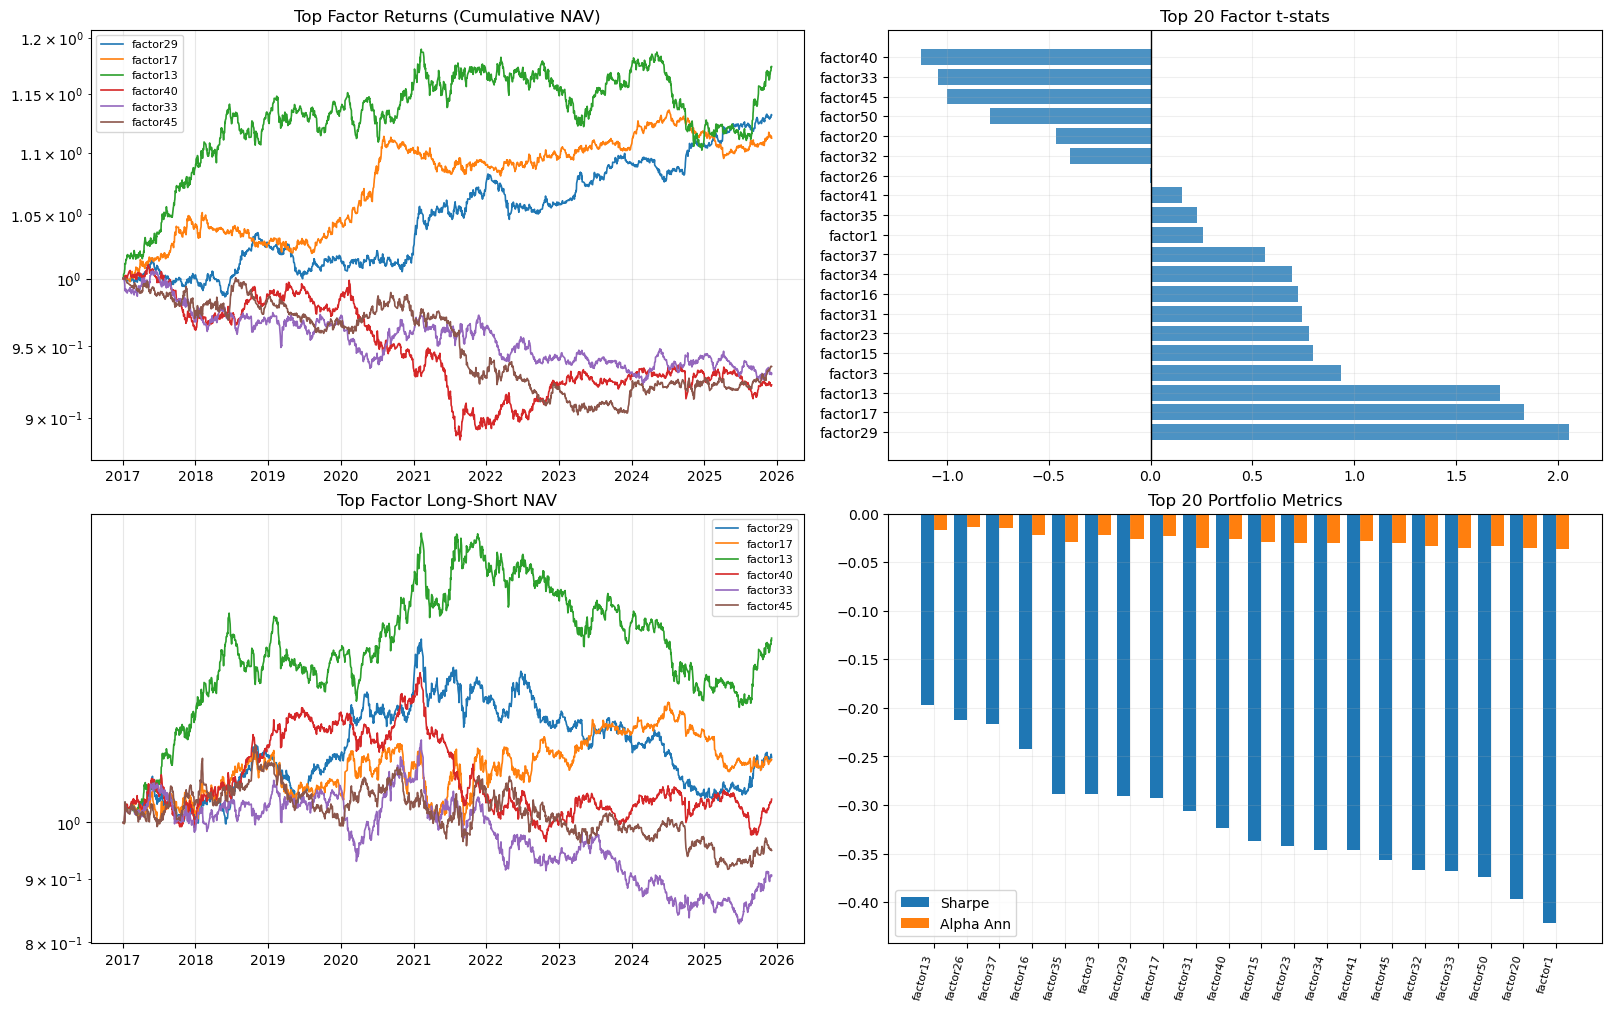

In [15]:
# ---------- Backtest visualization (from Cell 15 outputs) ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_vars = ["factor_ret_df", "port_df", "stat_df", "metric_df"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from Cell 15: {missing}. Please run Cell 15 first.")

top_fac = stat_df.reindex(stat_df["t"].abs().sort_values(ascending=False).index)["factor"].head(6).tolist()
if len(top_fac) == 0:
    raise RuntimeError("No factors available for visualization.")

# Unified plot start date: align long-short NAV with factor return sample start (should be around 2017)
factor_ret_dates = pd.to_datetime(factor_ret_df["date"], errors="coerce").dropna()
plot_start_date = factor_ret_dates.min() if len(factor_ret_dates) > 0 else None

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# (1) Factor return cumulative NAV
ax = axes[0, 0]
for fac in top_fac:
    if fac not in factor_ret_df.columns:
        continue
    s = factor_ret_df[["date", fac]].dropna().copy()
    s["date"] = pd.to_datetime(s["date"], errors="coerce")
    s = s.dropna(subset=["date"]).sort_values("date")
    if plot_start_date is not None:
        s = s[s["date"] >= plot_start_date]
    if s.empty:
        continue
    s["nav"] = (1 + s[fac]).cumprod()
    ax.plot(s["date"], s["nav"], label=fac, lw=1.2)
ax.set_title("Top Factor Returns (Cumulative NAV)")
ax.set_yscale("log", base=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# (2) Factor t-stats
ax = axes[0, 1]
plot_stats = stat_df.head(20).copy()
ax.barh(plot_stats["factor"], plot_stats["t"], color="tab:blue", alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.set_title("Top 20 Factor t-stats")
ax.grid(alpha=0.2)

# (3) Long-short portfolio NAV (aligned start date)
ax = axes[1, 0]
for fac in top_fac:
    s = port_df.loc[port_df["factor"] == fac, ["date", "ls_ret"]].copy()
    s["date"] = pd.to_datetime(s["date"], errors="coerce")
    s = s.dropna(subset=["date"]).sort_values("date")
    if plot_start_date is not None:
        s = s[s["date"] >= plot_start_date]
    if s.empty:
        continue
    s["nav"] = (1 + s["ls_ret"]).cumprod()
    ax.plot(s["date"], s["nav"], label=fac, lw=1.2)
ax.set_title("Top Factor Long-Short NAV")
ax.set_yscale("log", base=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# (4) Portfolio Sharpe / Alpha
ax = axes[1, 1]
show_m = metric_df.head(20).copy()
x = np.arange(len(show_m))
ax.bar(x - 0.2, show_m["sharpe"], width=0.4, label="Sharpe")
ax.bar(x + 0.2, show_m["alpha_ann"], width=0.4, label="Alpha Ann")
ax.set_xticks(x)
ax.set_xticklabels(show_m["factor"], rotation=75, ha="right", fontsize=8)
ax.set_title("Top 20 Portfolio Metrics")
ax.grid(alpha=0.2)
ax.legend()

plt.show()

### Step 7: Factor economic meaning table (deduplicated; keep backtest metric merges)

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

In [16]:
# ---------- Factor economic meaning table (deduplicated; keep backtest metric merges) ----------
cluster_df_local = None
if TEXT_FACTORS_CLUSTER_CSV.exists():
    cluster_df_local = pd.read_csv(TEXT_FACTORS_CLUSTER_CSV)

if cluster_df_local is not None and not cluster_df_local.empty:
    # Base rows: keep top_words from Stage I clusters
    sel = cluster_df_local[cluster_df_local["factor_name"].isin(factor_cols)].copy()

    meaning_rows = []
    for fac in factor_cols:
        row = sel.loc[sel["factor_name"] == fac]
        top_words = "" if row.empty else str(row.iloc[0].get("top_words", ""))
        meaning_rows.append({
            "factor": fac,
            "top_words": ", ".join([w.strip() for w in top_words.split(",")[:20]]),
        })

    meaning_df = pd.DataFrame(meaning_rows)

    # Reuse Stage IV enhanced labeling if available, to avoid duplicate theme logic in this cell
    enhanced_cols = ["factor", "theme", "economic_meaning"]
    if "meaning_enhanced" in globals() and isinstance(meaning_enhanced, pd.DataFrame):
        if all(c in meaning_enhanced.columns for c in enhanced_cols):
            meaning_df = meaning_df.merge(
                meaning_enhanced[enhanced_cols].drop_duplicates(subset=["factor"]),
                on="factor",
                how="left",
            )

    if "theme" not in meaning_df.columns:
        meaning_df["theme"] = ""
    if "economic_meaning" not in meaning_df.columns:
        meaning_df["economic_meaning"] = ""

    # Keep backtest/stat metric merges
    meaning_df = meaning_df.merge(stat_df[["factor", "t", "ann_mean", "sharpe"]], on="factor", how="left")
    meaning_df = meaning_df.merge(metric_df[["factor", "alpha_ann", "beta"]], on="factor", how="left")

    meaning_df = meaning_df[[
        "factor", "theme", "economic_meaning", "t", "ann_mean", "sharpe", "alpha_ann", "beta", "top_words"
    ]]

    meaning_df.to_csv(FACTOR_MEANING_CSV, index=False, encoding="utf-8-sig")
    print("Factor economic meaning table saved:", FACTOR_MEANING_CSV)
    print(meaning_df.head(20).to_string(index=False))
else:
    print("Factor meaning table skipped: missing Stage I cluster file")

Factor economic meaning table saved: d:\MFIN\7036\factor_economic_meaning_rolling90.csv
  factor theme economic_meaning         t  ann_mean    sharpe  alpha_ann      beta                                                                                                                                                              top_words
factor26                        -0.003476 -0.000026 -0.001186  -0.014258 -0.046505                     attitudes, categorize, consultant, denotes, dexin, exposing, impartiality, making, outstrip, pevs, six-to-twelve-month, underweight, watchful, xpb
factor17                         1.831568  0.012558  0.624733  -0.023240 -0.048634                                                                                               ameyou, arbitration, differently, kec, nhu, polycity, shortcomings, view
factor13                         1.713815  0.019194  0.584568  -0.016792 -0.032756                                                                                

### Step 8: Multi-factor strategy using ALL text_factors

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

All factors used: 50
Backtest start date: 2017-01-01
Weight rule: daily expanding-window t-stats using only history date < t
Top +weights (preview at start):
  factor  weight
 factor1    0.02
 factor2    0.02
 factor3    0.02
 factor4    0.02
 factor5    0.02
 factor6    0.02
 factor7    0.02
 factor8    0.02
 factor9    0.02
factor10    0.02
Top -weights (preview at start):
  factor  weight
factor41    0.02
factor42    0.02
factor43    0.02
factor44    0.02
factor45    0.02
factor46    0.02
factor47    0.02
factor48    0.02
factor49    0.02
factor50    0.02


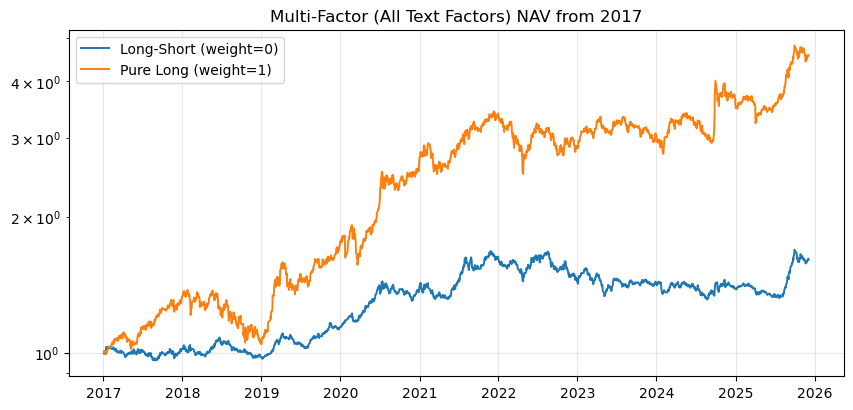

Saved:
 - d:\MFIN\7036\multi_factor_all_text_portfolio_daily.csv
 - d:\MFIN\7036\multi_factor_all_text_portfolio_metrics.csv
 - d:\MFIN\7036\multi_factor_all_text_portfolio_metrics_since2021.csv
Metrics (full sample):
         portfolio      ret      vol  alpha_ann      info   sharpe
long_short_weight0 0.611905 0.105868   0.036376 -0.592762 0.577364
 pure_long_weight1 3.574786 0.208316   0.014424  0.387828 0.953338
Metrics (since 2021-01-01):
         portfolio           period      ret      vol  alpha_ann      info  sharpe
long_short_weight0 since_2021-01-01 0.153716 0.116733   0.013351 -0.412904 0.31703
 pure_long_weight1 since_2021-01-01 0.707466 0.202099   0.013976  0.357695 0.66006


In [17]:
# ---------- Multi-factor strategy using ALL text_factors ----------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MULTI_PORT_RET_CSV = BASE_DIR / "multi_factor_all_text_portfolio_daily.csv"
MULTI_PORT_METRIC_CSV = BASE_DIR / "multi_factor_all_text_portfolio_metrics.csv"
MULTI_PORT_METRIC_2021_CSV = BASE_DIR / "multi_factor_all_text_portfolio_metrics_since2021.csv"
MULTI_TOP_Q = TOP_Q if "TOP_Q" in globals() else 0.2
MULTI_ANNUALIZATION = ANNUALIZATION if "ANNUALIZATION" in globals() else 252
MULTI_START_DATE = pd.Timestamp("2017-01-01")
MULTI_PERF_FROM_DATE = pd.Timestamp("2021-01-01")
MIN_WEIGHT_HISTORY_DAYS = 20

if "merged" not in globals() or not isinstance(merged, pd.DataFrame):
    raise RuntimeError("`merged` not found. Please run Cell 13 first.")

# Use all text factor columns in merged (not only selected robust factors)
all_factor_cols = [c for c in merged.columns if re.fullmatch(r"factor\d+", str(c))]
if len(all_factor_cols) == 0:
    raise RuntimeError("No factor columns like factor1/factor2/... found in `merged`.")

merged_multi = merged.copy()
merged_multi["date"] = pd.to_datetime(merged_multi["date"], errors="coerce")
merged_multi = merged_multi.dropna(subset=["date"]).copy()
merged_multi = merged_multi[merged_multi["date"] >= MULTI_START_DATE].copy()
if merged_multi.empty:
    raise RuntimeError(f"No data after start date {MULTI_START_DATE.date()} for multi-factor backtest.")

# Build historical daily factor-return table (from cross-sectional regression outputs) for dynamic OOS weights
if "pre_df" not in globals() or not isinstance(pre_df, pd.DataFrame):
    raise RuntimeError("`pre_df` not found. Please run Cell 15 first.")

hist_factor_ret = pre_df.copy()
hist_factor_ret["date"] = pd.to_datetime(hist_factor_ret["date"], errors="coerce")
hist_factor_ret = hist_factor_ret.dropna(subset=["date"]).copy()
use_hist_cols = [c for c in all_factor_cols if c in hist_factor_ret.columns]
if len(use_hist_cols) == 0:
    raise RuntimeError("No overlapping factor columns between `merged` and `pre_df`.")
hist_factor_ret = hist_factor_ret[["date", *use_hist_cols]].sort_values("date").reset_index(drop=True)

def calc_hist_t_weights(hist_df: pd.DataFrame, fac_cols: list):
    t_vals = []
    for fac in fac_cols:
        s = pd.to_numeric(hist_df[fac], errors="coerce").dropna()
        n = len(s)
        if n < 2:
            t_vals.append(0.0)
            continue
        std = float(s.std(ddof=1))
        if std <= 1e-12:
            t_vals.append(0.0)
            continue
        t_vals.append(float(s.mean() / (std / np.sqrt(n))))
    w = np.asarray(t_vals, dtype=float)
    if np.all(np.abs(w) < 1e-12):
        w = np.ones(len(fac_cols), dtype=float)
    w = w / (np.sum(np.abs(w)) + 1e-12)
    return w

init_hist = hist_factor_ret[hist_factor_ret["date"] < merged_multi["date"].min()]
if len(init_hist) >= MIN_WEIGHT_HISTORY_DAYS:
    w_preview = calc_hist_t_weights(init_hist, all_factor_cols)
else:
    w_preview = np.ones(len(all_factor_cols), dtype=float)
    w_preview = w_preview / (np.sum(np.abs(w_preview)) + 1e-12)

weights_df = pd.DataFrame({"factor": all_factor_cols, "weight": w_preview}).sort_values("weight", ascending=False)
print("All factors used:", len(all_factor_cols))
print("Backtest start date:", MULTI_START_DATE.date())
print("Weight rule: daily expanding-window t-stats using only history date < t")
print("Top +weights (preview at start):")
print(weights_df.head(10).to_string(index=False))
print("Top -weights (preview at start):")
print(weights_df.tail(10).to_string(index=False))

rows = []
for dt, dfg in merged_multi.groupby("date", sort=True):
    hist = hist_factor_ret[hist_factor_ret["date"] < dt]
    if len(hist) >= MIN_WEIGHT_HISTORY_DAYS:
        w_t = calc_hist_t_weights(hist, all_factor_cols)
    else:
        w_t = np.ones(len(all_factor_cols), dtype=float)
        w_t = w_t / (np.sum(np.abs(w_t)) + 1e-12)

    x = dfg[["stock", "target_ret", *all_factor_cols]].dropna(subset=["target_ret"]).copy()
    if len(x) < max(MIN_STOCKS_PER_DAY if "MIN_STOCKS_PER_DAY" in globals() else 20, 10):
        continue

    X = x[all_factor_cols].to_numpy(dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[sd < 1e-12] = np.nan
    Z = (X - mu) / sd
    Z = np.nan_to_num(Z, nan=0.0)

    x["score"] = Z @ w_t
    x = x.replace([np.inf, -np.inf], np.nan).dropna(subset=["score", "target_ret"])
    n = len(x)
    if n < max(MIN_STOCKS_PER_DAY if "MIN_STOCKS_PER_DAY" in globals() else 20, 10):
        continue

    k = max(1, int(n * MULTI_TOP_Q))
    x = x.sort_values("score")

    # Standard market-neutral long-short (sum weights = 0)
    short_ret = float(x.head(k)["target_ret"].mean())
    long_ret = float(x.tail(k)["target_ret"].mean())
    ls_ret = long_ret - short_ret

    # Pure long portfolio (sum weights = 1): long top-k equally weighted
    pure_long_ret = long_ret

    rows.append({
        "date": dt,
        "n": int(n),
        "k": int(k),
        "long_ret": long_ret,
        "short_ret": short_ret,
        "ls_ret": ls_ret,
        "pure_long_ret": pure_long_ret,
    })

multi_port_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
if multi_port_df.empty:
    raise RuntimeError("Multi-factor portfolio is empty. Check data coverage in `merged`.")

multi_port_df.to_csv(MULTI_PORT_RET_CSV, index=False, encoding="utf-8-sig")

mkt = merged_multi.groupby("date", as_index=False)["target_ret"].mean().rename(columns={"target_ret": "mkt_ret"})
perf = multi_port_df.merge(mkt, on="date", how="left").dropna(subset=["mkt_ret"]).copy()
perf["date"] = pd.to_datetime(perf["date"], errors="coerce")

def calc_metrics(ret_series: pd.Series, mkt_series: pd.Series):
    r = pd.to_numeric(ret_series, errors="coerce").dropna().to_numpy(dtype=float)
    m = pd.to_numeric(mkt_series.loc[ret_series.index], errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(r) & np.isfinite(m)
    r = r[valid]
    m = m[valid]
    n = len(r)
    if n <= 1:
        return dict(n=n, ret=np.nan, mean=np.nan, std=np.nan, vol=np.nan, sharpe=np.nan, info=np.nan, beta=np.nan, alpha_ann=np.nan)
    mean = float(np.mean(r))
    std = float(np.std(r, ddof=1))
    vol = float(std * np.sqrt(MULTI_ANNUALIZATION))
    sharpe = (mean * MULTI_ANNUALIZATION) / (std * np.sqrt(MULTI_ANNUALIZATION)) if std > 1e-12 else np.nan
    nav = np.cumprod(1 + r)
    ret = float(nav[-1] - 1)
    active = r - m
    te = float(np.std(active, ddof=1)) if len(active) > 1 else np.nan
    info = (float(np.mean(active)) * MULTI_ANNUALIZATION) / (te * np.sqrt(MULTI_ANNUALIZATION)) if (pd.notna(te) and te > 1e-12) else np.nan
    var_m = float(np.var(m, ddof=1)) if len(m) > 1 else np.nan
    beta = float(np.cov(r, m, ddof=1)[0, 1] / var_m) if (pd.notna(var_m) and var_m > 1e-12) else np.nan
    alpha_daily = float(mean - beta * np.mean(m)) if pd.notna(beta) else np.nan
    alpha_ann = float(alpha_daily * MULTI_ANNUALIZATION) if pd.notna(alpha_daily) else np.nan
    return dict(n=n, ret=ret, mean=mean, std=std, vol=vol, sharpe=sharpe, info=info, beta=beta, alpha_ann=alpha_ann)

# Full-sample metrics (existing output compatibility)
metric_ls = calc_metrics(perf["ls_ret"], perf["mkt_ret"])
metric_pl = calc_metrics(perf["pure_long_ret"], perf["mkt_ret"])

multi_metric_df = pd.DataFrame([
    {"portfolio": "long_short_weight0", **metric_ls},
    {"portfolio": "pure_long_weight1", **metric_pl},
])
multi_metric_df.to_csv(MULTI_PORT_METRIC_CSV, index=False, encoding="utf-8-sig")

# Since-2021 metrics (requested)
perf_2021 = perf[perf["date"] >= MULTI_PERF_FROM_DATE].copy()
metric_2021_ls = calc_metrics(perf_2021["ls_ret"], perf_2021["mkt_ret"]) if not perf_2021.empty else calc_metrics(pd.Series(dtype=float), pd.Series(dtype=float))
metric_2021_pl = calc_metrics(perf_2021["pure_long_ret"], perf_2021["mkt_ret"]) if not perf_2021.empty else calc_metrics(pd.Series(dtype=float), pd.Series(dtype=float))

multi_metric_2021_df = pd.DataFrame([
    {"portfolio": "long_short_weight0", "period": f"since_{MULTI_PERF_FROM_DATE.date()}", **metric_2021_ls},
    {"portfolio": "pure_long_weight1", "period": f"since_{MULTI_PERF_FROM_DATE.date()}", **metric_2021_pl},
])
multi_metric_2021_df.to_csv(MULTI_PORT_METRIC_2021_CSV, index=False, encoding="utf-8-sig")

# Plot NAVs (from 2017)
plot_df = multi_port_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
plot_df = plot_df.dropna(subset=["date"]).sort_values("date")
plot_df = plot_df[plot_df["date"] >= MULTI_START_DATE].copy()
plot_df["nav_ls"] = (1 + plot_df["ls_ret"]).cumprod()
plot_df["nav_pure_long"] = (1 + plot_df["pure_long_ret"]).cumprod()

plt.figure(figsize=(10, 4.5))
plt.plot(plot_df["date"], plot_df["nav_ls"], lw=1.4, label="Long-Short (weight=0)")
plt.plot(plot_df["date"], plot_df["nav_pure_long"], lw=1.4, label="Pure Long (weight=1)")
plt.yscale("log", base=10)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Multi-Factor (All Text Factors) NAV from 2017")
plt.show()

print("Saved:")
print(" -", MULTI_PORT_RET_CSV)
print(" -", MULTI_PORT_METRIC_CSV)
print(" -", MULTI_PORT_METRIC_2021_CSV)
print("Metrics (full sample):")
print(multi_metric_df[["portfolio", "ret", "vol", "alpha_ann", "info", "sharpe"]].to_string(index=False))
print(f"Metrics (since {MULTI_PERF_FROM_DATE.date()}):")
print(multi_metric_2021_df[["portfolio", "period", "ret", "vol", "alpha_ann", "info", "sharpe"]].to_string(index=False))

# Stage IV Visualization

In [18]:
# ---------- Stage III v2 post-processing: single-layer themes (no sub-layer) + embedding-prototype similarity labeling ----------
from pathlib import Path
import numpy as np
import pandas as pd
import pickle

THEME_ENHANCED_OUT = BASE_DIR / "factor_economic_meaning_rolling90_enhanced.csv"
TOP_WORDS_USED = 20
SUMMARY_WORDS_K = 8

cluster_path = TEXT_FACTORS_CLUSTER_CSV if "TEXT_FACTORS_CLUSTER_CSV" in globals() else (BASE_DIR / "text_factors_stage1_clusters.csv")
if not Path(cluster_path).exists():
    raise FileNotFoundError(f"Missing cluster file: {cluster_path}")
cluster_df_local = pd.read_csv(cluster_path)

USE_ALL_FACTORS_FOR_THEME = True
if USE_ALL_FACTORS_FOR_THEME:
    selected_factors = sorted(cluster_df_local["factor_name"].dropna().astype(str).unique().tolist())
else:
    if "factor_cols" in globals() and isinstance(factor_cols, list) and len(factor_cols) > 0:
        selected_factors = list(factor_cols)
    else:
        stat_candidates = [
            BASE_DIR / "factor_significance_summary_rolling90.csv",
            BASE_DIR / "factor_significance_summary_90d.csv",
            BASE_DIR / "factor_significance_summary.csv",
        ]
        stat_path = next((p for p in stat_candidates if p.exists()), None)
        if stat_path is None:
            raise FileNotFoundError("No factor_significance_summary*.csv found")
        stat_df_tmp = pd.read_csv(stat_path)
        selected_factors = stat_df_tmp["factor"].astype(str).tolist()

sel = cluster_df_local[cluster_df_local["factor_name"].astype(str).isin(selected_factors)].copy()
if sel.empty:
    raise RuntimeError("No matching factors found in cluster file for selected factor set")
print("Theme labeling factors:", len(selected_factors))

# Single-layer theme taxonomy (industry-specific themes and macro themes are at the same level)
unified_theme_rules = {
    "Growth & Investment": ["growth", "expansion", "capex", "investment", "demand", "revenue", "sales", "volume"],
    "Profitability & Margin": ["profit", "margin", "earnings", "ebit", "roe", "net", "cost", "expense"],
    "Leverage & Credit": ["debt", "leverage", "credit", "liability", "default", "financing", "loan", "bond"],
    "Liquidity & Cash Flow": ["cash", "liquidity", "working", "capital", "turnover", "inventory", "receivable"],
    "Valuation & Sentiment": ["valuation", "multiple", "pe", "pb", "premium", "discount", "sentiment", "expectation"],
    "Policy & Regulation": ["policy", "regulation", "approval", "subsidy", "tariff", "government", "compliance"],
    "Commodity & Input Cost": ["commodity", "oil", "coal", "metal", "copper", "steel", "material", "input"],
    "Technology & Product Cycle": ["technology", "ai", "chip", "software", "product", "launch", "innovation", "model"],
    "Regional Theme": ["china", "asia", "europe", "us", "america", "japan", "korea", "india", "asean", "hongkong", "shanghai", "shenzhen", "beijing", "guangdong", "yangtze", "greaterbay"],
    "Real Estate": ["realestate", "property", "developer", "housing", "reit", "mortgage", "land", "presale"],
    "Banking": ["bank", "deposit", "loan", "interest", "nim", "npl", "credit"],
    "Brokerage": ["broker", "securities", "trading", "commission", "ipo", "margin-financing"],
    "Insurance": ["insurance", "premium", "actuarial", "life", "pnc"],
    "Automobile": ["auto", "vehicle", "ev", "battery", "oem", "dealership"],
    "Pharma & Biotech": ["pharma", "biotech", "drug", "hospital", "clinical", "vaccine", "medical"],
    "Semiconductor": ["chip", "semiconductor", "foundry", "wafer", "fab", "ic", "memory"],
    "Energy & Utility": ["energy", "power", "utility", "grid", "renewable", "solar", "wind"],
    "Coal & Steel": ["coal", "steel", "coke", "blast", "ironore", "metallurgy"],
    "Consumer": ["consumer", "retail", "food", "beverage", "brand", "channel"],
    "TMT": ["telecom", "media", "internet", "software", "cloud", "platform"],
}

theme_group = {
    "Growth & Investment": "Macro/Style",
    "Profitability & Margin": "Macro/Style",
    "Leverage & Credit": "Macro/Style",
    "Liquidity & Cash Flow": "Macro/Style",
    "Valuation & Sentiment": "Macro/Style",
    "Policy & Regulation": "Macro/Style",
    "Commodity & Input Cost": "Macro/Style",
    "Technology & Product Cycle": "Macro/Style",
    "Regional Theme": "Region",
    "Real Estate": "Industry",
    "Banking": "Industry",
    "Brokerage": "Industry",
    "Insurance": "Industry",
    "Automobile": "Industry",
    "Pharma & Biotech": "Industry",
    "Semiconductor": "Industry",
    "Energy & Utility": "Industry",
    "Coal & Steel": "Industry",
    "Consumer": "Industry",
    "TMT": "Industry",
    "Mixed/Other": "Other",
}

econ_meaning = {
    "Growth & Investment": "Demand expansion and capex cycles, typically linked to revenue acceleration and higher market beta.",
    "Profitability & Margin": "Shifts in profitability and cost discipline that drive valuation repricing and persistence of excess returns.",
    "Leverage & Credit": "Balance-sheet risk and financing constraints that affect tail risk and required risk premium.",
    "Liquidity & Cash Flow": "Cash-flow quality and working-capital efficiency that shape defensiveness and drawdown resilience.",
    "Valuation & Sentiment": "Valuation gaps and expectation revisions, often expressed through mean reversion or expectation-correction trades.",
    "Policy & Regulation": "Policy shocks and regulatory constraints that reprice sectors and create event-driven return dispersion.",
    "Commodity & Input Cost": "Upstream price changes and cost pass-through that influence margins and sector-relative performance.",
    "Technology & Product Cycle": "Technology iteration and product cycles that determine growth slope and valuation elasticity.",
    "Regional Theme": "Regional macro, geopolitics, and local policy shifts that drive relative valuation and capital preference.",
    "Real Estate": "Property-cycle, sales, and financing-condition changes that dominate sector-relative returns.",
    "Banking": "Credit expansion, net-interest-margin, and asset-quality dynamics that drive bank valuation and returns.",
    "Brokerage": "Capital-market activity and brokerage/investment-banking cycles that determine broker earnings elasticity.",
    "Insurance": "Premium growth, asset-side yields, and liability-duration matching that shape insurer performance.",
    "Automobile": "Sales trend, product mix, and EV-penetration dynamics that drive auto-chain returns.",
    "Pharma & Biotech": "R&D progress, policy access, and commercialization pace that influence healthcare repricing.",
    "Semiconductor": "Cycle, capacity, and technology-node shifts that determine semiconductor profit elasticity.",
    "Energy & Utility": "Power and fuel-price dynamics plus utility regulation that affect cash flows and valuation anchors.",
    "Coal & Steel": "Commodity pricing, supply-demand balance, and cost pass-through that drive coal/steel earnings volatility.",
    "Consumer": "Demand resilience, channel efficiency, and brand pricing power that determine consumer-sector alpha.",
    "TMT": "Technology innovation and monetization of content/traffic that shape TMT growth trajectory.",
    "Mixed/Other": "Mixed themes or weak signals with no single dominant economic interpretation.",
}

embedding_dict = None
if "word_to_vec_final" in globals() and isinstance(word_to_vec_final, dict) and len(word_to_vec_final) > 0:
    embedding_dict = word_to_vec_final
else:
    emb_path = BASE_DIR / "embedding_word_to_vec.pkl"
    if emb_path.exists():
        with open(emb_path, "rb") as f:
            embedding_dict = pickle.load(f)

if embedding_dict is None or len(embedding_dict) == 0:
    raise RuntimeError("Embedding dict not found. This step requires embedding similarity for labeling.")

emb_vocab = list(embedding_dict.keys())
emb_mat = np.vstack([np.asarray(embedding_dict[w], dtype=float) for w in emb_vocab])
emb_mat = emb_mat / (np.linalg.norm(emb_mat, axis=1, keepdims=True) + 1e-12)

def parse_top_words(s, k=20):
    return [t.strip().lower() for t in str(s).split(",") if t.strip()][:k]

def cosine(a, b):
    return float(np.dot(a, b) / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))

def build_prototype(keyword_list):
    vecs = [np.asarray(embedding_dict[w], dtype=float) for w in keyword_list if w in embedding_dict]
    if len(vecs) == 0:
        return None
    c = np.mean(np.vstack(vecs), axis=0)
    return c / (np.linalg.norm(c) + 1e-12)

theme_prototypes = {name: build_prototype(kws) for name, kws in unified_theme_rules.items()}
valid_theme_names = [k for k, v in theme_prototypes.items() if v is not None]
if len(valid_theme_names) == 0:
    raise RuntimeError("No valid theme prototypes could be built from embedding dictionary.")

def factor_centroid(top_tokens):
    vecs = [np.asarray(embedding_dict[t], dtype=float) for t in top_tokens if t in embedding_dict]
    if len(vecs) == 0:
        return None
    c = np.mean(np.vstack(vecs), axis=0)
    return c / (np.linalg.norm(c) + 1e-12)

def summarize_by_embedding(top_tokens):
    c = factor_centroid(top_tokens)
    if c is None:
        return ", ".join(top_tokens[:5])
    sims = emb_mat @ c
    top_idx = np.argsort(-sims)[: (SUMMARY_WORDS_K * 3)]
    picked = []
    top_set = set(top_tokens)
    for i in top_idx:
        w = emb_vocab[int(i)]
        if w in top_set:
            continue
        picked.append(w)
        if len(picked) >= SUMMARY_WORDS_K:
            break
    return ", ".join(picked if picked else top_tokens[:SUMMARY_WORDS_K])

def classify_by_embedding(top_tokens):
    c = factor_centroid(top_tokens)
    if c is None:
        return "Mixed/Other", np.nan, "", np.nan, np.nan
    scored = sorted([(nm, cosine(c, theme_prototypes[nm])) for nm in valid_theme_names], key=lambda x: x[1], reverse=True)
    best_theme, best_sim = scored[0]
    second_theme, second_sim = (scored[1] if len(scored) > 1 else ("", np.nan))
    margin = float(best_sim - second_sim) if pd.notna(second_sim) else np.nan
    return best_theme, float(best_sim), second_theme, float(second_sim) if pd.notna(second_sim) else np.nan, margin

rows = []
for fac in selected_factors:
    row = sel.loc[sel["factor_name"].astype(str) == str(fac)]
    top_words = "" if row.empty else str(row.iloc[0].get("top_words", ""))
    top_tokens = parse_top_words(top_words, k=TOP_WORDS_USED)
    theme, theme_sim, second_theme, second_sim, margin = classify_by_embedding(top_tokens)
    rows.append({
        "factor": str(fac),
        "theme": theme,
        "theme_group": theme_group.get(theme, "Other"),
        "theme_similarity": float(theme_sim) if pd.notna(theme_sim) else np.nan,
        "second_theme": second_theme,
        "second_theme_similarity": float(second_sim) if pd.notna(second_sim) else np.nan,
        "similarity_margin": float(margin) if pd.notna(margin) else np.nan,
        "economic_meaning": econ_meaning.get(theme, econ_meaning["Mixed/Other"]),
        "top_words": ", ".join(top_tokens),
        "embedding_summary_words": summarize_by_embedding(top_tokens),
    })

meaning_enhanced = pd.DataFrame(rows)

stat_candidates = [BASE_DIR / "factor_significance_summary_rolling90.csv", BASE_DIR / "factor_significance_summary_90d.csv", BASE_DIR / "factor_significance_summary.csv"]
metric_candidates = [BASE_DIR / "factor_portfolio_metrics_rolling90.csv", BASE_DIR / "factor_portfolio_metrics_90d.csv", BASE_DIR / "factor_portfolio_metrics.csv"]
stat_path = next((p for p in stat_candidates if p.exists()), None)
metric_path = next((p for p in metric_candidates if p.exists()), None)

if stat_path is not None:
    stat_df_merge = pd.read_csv(stat_path)
    keep_cols = [c for c in ["factor", "t", "ann_mean", "sharpe"] if c in stat_df_merge.columns]
    if len(keep_cols) > 1:
        meaning_enhanced = meaning_enhanced.merge(stat_df_merge[keep_cols], on="factor", how="left")

if metric_path is not None:
    metric_df_merge = pd.read_csv(metric_path)
    keep_cols = [c for c in ["factor", "alpha_ann", "beta", "cum_ret"] if c in metric_df_merge.columns]
    if len(keep_cols) > 1:
        meaning_enhanced = meaning_enhanced.merge(metric_df_merge[keep_cols], on="factor", how="left")

ordered = [
    "factor", "theme", "theme_group", "theme_similarity",
    "second_theme", "second_theme_similarity", "similarity_margin",
    "economic_meaning",
    "t", "ann_mean", "sharpe", "alpha_ann", "beta", "cum_ret",
    "top_words", "embedding_summary_words",
]
meaning_enhanced = meaning_enhanced[[c for c in ordered if c in meaning_enhanced.columns]]

meaning_enhanced.to_csv(THEME_ENHANCED_OUT, index=False, encoding="utf-8-sig")
print("Enhanced theme-economic meaning saved:", THEME_ENHANCED_OUT)
print(meaning_enhanced.head(20).to_string(index=False))

Theme labeling factors: 50
Enhanced theme-economic meaning saved: d:\MFIN\7036\factor_economic_meaning_rolling90_enhanced.csv
  factor                      theme theme_group  theme_similarity               second_theme  second_theme_similarity  similarity_margin                                                                                                   economic_meaning         t  ann_mean    sharpe  alpha_ann      beta   cum_ret                                                                                                                                                              top_words                                                                                             embedding_summary_words
 factor1                  Brokerage    Industry          0.451581          Leverage & Credit                 0.443662           0.007919         Capital-market activity and brokerage/investment-banking cycles that determine broker earnings elasticity.  0.259320  0.002073  0.088

### Step 9: Top-theme word cloud visualization (single-layer themes; cleaned + generalized weighted TF-IDF)

**Role**
- Executes the next processing block in the LSH + topic pipeline.

**Logic**
- Initializes inputs/configs, applies the core transformation, and stores intermediate results.
- Includes guardrails so downstream cells receive consistent data structures.

**Output**
- Produces in-memory objects and/or files used by subsequent steps.

Using report-level prevalence weighting. pairs=515


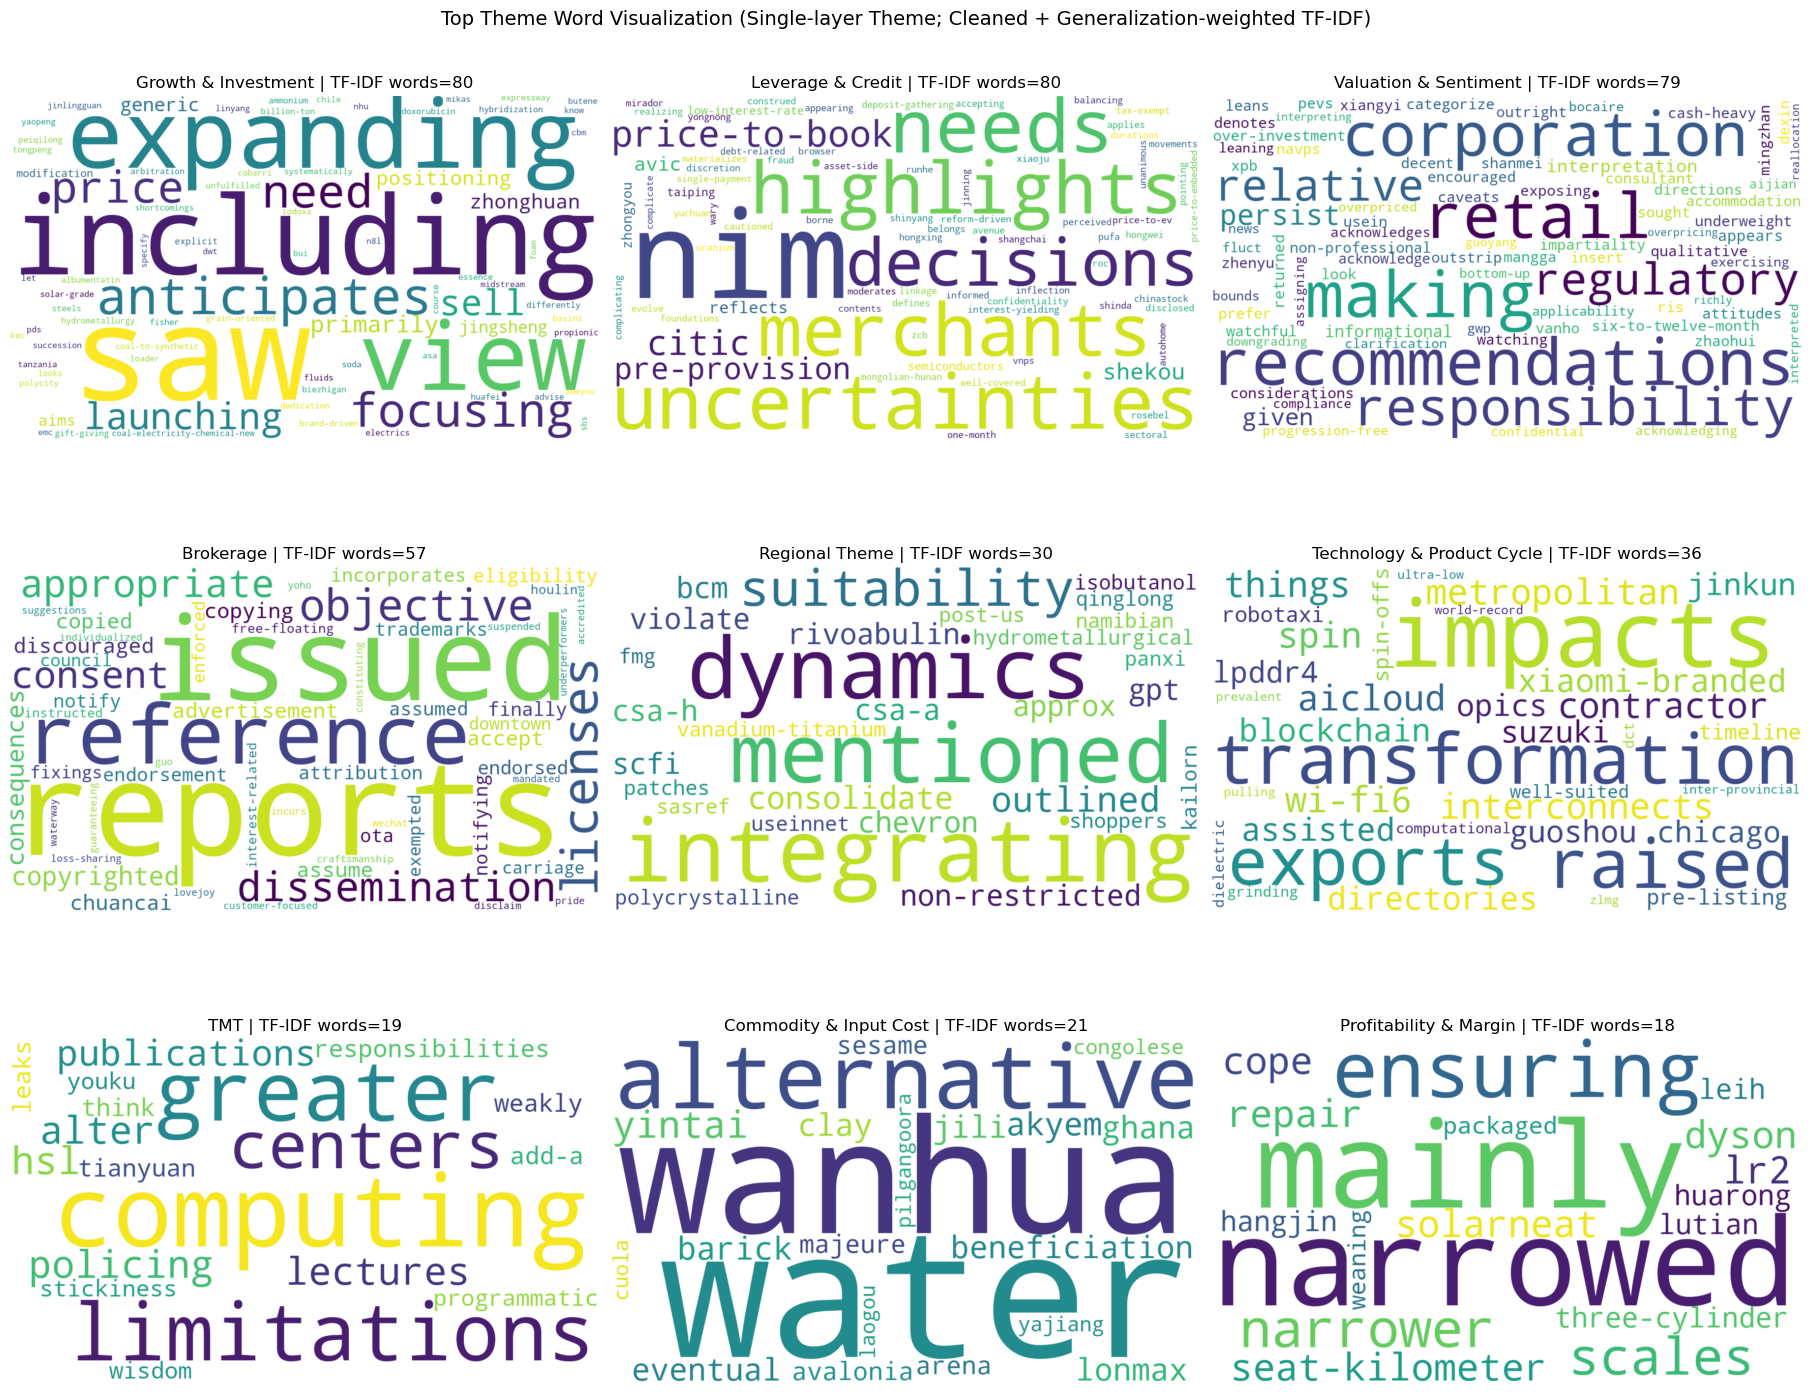

Top themes: ['Growth & Investment', 'Leverage & Credit', 'Valuation & Sentiment', 'Brokerage', 'Regional Theme', 'Technology & Product Cycle', 'TMT', 'Commodity & Input Cost', 'Profitability & Margin']
Saved theme figure: d:\MFIN\7036\top_theme_wordclouds_tfidf_rolling90.png
Saved theme TF-IDF table: d:\MFIN\7036\top_theme_words_tfidf_rolling90.csv
Theme TF-IDF preview:
    theme          word    tfidf  tf_weighted      idf
Brokerage       reports 2.453184     0.940120 2.609438
Brokerage        issued 1.880545     0.720670 2.609438
Brokerage     reference 1.878623     0.719934 2.609438
Brokerage      licenses 0.422758     0.162011 2.609438
Brokerage     objective 0.318119     0.121911 2.609438
Brokerage dissemination 0.275629     0.105628 2.609438
Brokerage   appropriate 0.240739     0.092257 2.609438
Brokerage       consent 0.237222     0.090909 2.609438
Brokerage   copyrighted 0.194296     0.074459 2.609438
Brokerage  consequences 0.183000     0.070130 2.609438
Brokerage        accep

In [19]:
# ---------- Top-theme word cloud visualization (single-layer themes; cleaned + generalized weighted TF-IDF) ----------
from collections import Counter
import math
import re
import numpy as np
import matplotlib.pyplot as plt

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except Exception:
    HAS_WORDCLOUD = False
    print("wordcloud is not installed. Falling back to TF-IDF bar charts. Install it with: %pip install wordcloud")

TOP_THEME_N = 9
TOP_WORDS_PER_GROUP = 80
WORDCLOUD_MAX_WORDS = 120
WORDCLOUD_BG = "white"

PREVALENCE_FLOOR = 0.05
PREVALENCE_POWER = 1.0

THEME_CLOUD_PNG = BASE_DIR / "top_theme_wordclouds_tfidf_rolling90.png"
THEME_TFIDF_CSV = BASE_DIR / "top_theme_words_tfidf_rolling90.csv"

MIN_TOKEN_LEN = 3
MAX_TOKEN_LEN = 30
MAX_DIGIT_RATIO = 0.35
MAX_HYPHEN_PARTS = 4

extra_stopwords = {
    "hse", "hbc", "csc", "camb", "cagr", "roe", "roa", "ebit", "eps",
    "yuan", "million-yuan", "check-up", "scale-up", "start-up", "back-end",
    "non-true", "full-scale", "high-cost", "initial", "extent", "scope",
}

if "meaning_enhanced" in globals() and isinstance(meaning_enhanced, pd.DataFrame):
    base_df = meaning_enhanced.copy()
else:
    fallback_path = BASE_DIR / "factor_economic_meaning_rolling90_enhanced.csv"
    if not fallback_path.exists():
        raise FileNotFoundError(f"Missing enhanced theme file: {fallback_path}")
    base_df = pd.read_csv(fallback_path)

if "theme" not in base_df.columns or "top_words" not in base_df.columns or "factor" not in base_df.columns:
    raise ValueError("Need columns: factor, theme, top_words")

def clean_token(token: str):
    t = str(token).strip().lower()
    if not t:
        return None
    t = re.sub(r"\s+", "", t)
    t = re.sub(r"[^a-z0-9_-]", "", t)
    if not t:
        return None
    if len(t) < MIN_TOKEN_LEN or len(t) > MAX_TOKEN_LEN:
        return None
    if t in extra_stopwords:
        return None
    alpha_cnt = sum(ch.isalpha() for ch in t)
    digit_cnt = sum(ch.isdigit() for ch in t)
    if alpha_cnt < 2:
        return None
    if digit_cnt / max(len(t), 1) > MAX_DIGIT_RATIO:
        return None
    if t.count("-") + t.count("_") >= MAX_HYPHEN_PARTS:
        return None
    if "ENTITY_STOPWORDS" in globals() and isinstance(ENTITY_STOPWORDS, set):
        if t in ENTITY_STOPWORDS:
            return None
    return t

def tokenize_top_words(text: str):
    raw = [w.strip() for w in str(text).split(",") if w.strip()]
    return [c for c in (clean_token(w) for w in raw) if c is not None]

prevalence_map = {}
has_report_level_prevalence = False
try:
    if ("text_factors" in globals() and isinstance(text_factors, list) and len(text_factors) > 0
            and "word_doc_counts" in globals() and isinstance(word_doc_counts, dict)):
        factor_support = {str(f.get("name", "")).strip(): [str(w).lower() for w in f.get("Si", [])] for f in text_factors if str(f.get("name", "")).strip()}
        for _, r in base_df.iterrows():
            fac = str(r.get("factor", "")).strip()
            if not fac:
                continue
            top_tokens = tokenize_top_words(r.get("top_words", ""))
            if len(top_tokens) == 0:
                continue
            support_words = factor_support.get(fac, top_tokens)
            docs_union = set()
            for w in support_words:
                docs_union.update(word_doc_counts.get(w, {}).keys())
            n_docs = len(docs_union)
            for w in top_tokens:
                wd = set(word_doc_counts.get(w, {}).keys())
                p = (len(wd.intersection(docs_union)) / float(n_docs)) if n_docs > 0 else 0.0
                prevalence_map[(fac, w)] = max(PREVALENCE_FLOOR, float(p))
        has_report_level_prevalence = len(prevalence_map) > 0
except Exception as e:
    print("Prevalence map build warning:", e)

if has_report_level_prevalence:
    print(f"Using report-level prevalence weighting. pairs={len(prevalence_map)}")
else:
    print("Report-level prevalence unavailable; fallback to equal token weight (=1.0).")

def word_weight(factor_name: str, token: str):
    p = prevalence_map.get((str(factor_name), str(token)), 1.0)
    return float(max(PREVALENCE_FLOOR, p) ** PREVALENCE_POWER)

def compute_group_tfidf(df_in: pd.DataFrame, group_col: str, top_n_groups: int, out_csv: Path):
    tmp = df_in.copy()
    tmp[group_col] = tmp[group_col].fillna("").astype(str).str.strip()
    tmp = tmp[tmp[group_col] != ""]
    if len(tmp) == 0:
        return [], {}, pd.DataFrame(columns=[group_col, "word", "tfidf", "tf_weighted", "idf"])
    if "t" in tmp.columns:
        rank_df = tmp.groupby(group_col, as_index=False).agg(
            n_factors=(group_col, "size"),
            mean_abs_t=("t", lambda s: float(pd.to_numeric(s, errors="coerce").abs().mean()))
        )
        rank_df["score"] = rank_df["n_factors"] * (1.0 + rank_df["mean_abs_t"].fillna(0.0))
        top_groups = rank_df.sort_values(["score", "n_factors"], ascending=False)[group_col].head(top_n_groups).tolist()
    else:
        top_groups = tmp[group_col].value_counts().head(top_n_groups).index.tolist()

    # If valid themes are fewer than top_n_groups, pad with predefined theme prototypes to keep the subplot layout complete
    if group_col == "theme" and len(top_groups) < top_n_groups and "unified_theme_rules" in globals() and isinstance(unified_theme_rules, dict):
        candidates = [g for g in unified_theme_rules.keys() if g not in top_groups]
        top_groups.extend(candidates[: max(0, top_n_groups - len(top_groups))])

    group_tf = {}
    for g in top_groups:
        sub = tmp.loc[tmp[group_col] == g, ["factor", "top_words"]].copy()
        counter = Counter()
        for _, rr in sub.iterrows():
            fac = str(rr.get("factor", ""))
            for tk in tokenize_top_words(rr.get("top_words", "")):
                counter[tk] += word_weight(fac, tk)
        if len(counter) == 0 and group_col == "theme" and "unified_theme_rules" in globals() and g in unified_theme_rules:
            for kw in unified_theme_rules.get(g, []):
                ck = clean_token(kw)
                if ck is not None:
                    counter[ck] += 1.0
        group_tf[g] = counter

    docs = [set(c.keys()) for c in group_tf.values()]
    N = len(docs)
    df_counter = Counter()
    for dset in docs:
        df_counter.update(dset)
    idf = {w: math.log((1 + N) / (1 + df)) + 1.0 for w, df in df_counter.items()}

    group_tfidf = {}
    rows_export = []
    for g in top_groups:
        tf_counter = group_tf[g]
        scored = {w: float(tf_w) * float(idf.get(w, 1.0)) for w, tf_w in tf_counter.items()}
        scored_sorted = sorted(scored.items(), key=lambda kv: kv[1], reverse=True)[:TOP_WORDS_PER_GROUP]
        group_tfidf[g] = dict(scored_sorted)
        for w, s in scored_sorted:
            rows_export.append({group_col: g, "word": w, "tfidf": float(s), "tf_weighted": float(tf_counter[w]), "idf": float(idf.get(w, 1.0))})

    out_df = pd.DataFrame(rows_export).sort_values([group_col, "tfidf"], ascending=[True, False])
    out_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    return top_groups, group_tfidf, out_df

def plot_group_clouds(group_names, tfidf_map, title_prefix, save_path):
    if len(group_names) == 0:
        print(f"{title_prefix}: no groups to plot")
        return
    n = len(group_names)
    ncols = 3 if n >= 3 else n
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)
    for i, g in enumerate(group_names):
        ax = axes[i]
        freq_dict = tfidf_map.get(g, {})
        if len(freq_dict) == 0:
            ax.set_title(f"{g} (no valid words)")
            ax.axis("off")
            continue
        if HAS_WORDCLOUD:
            wc = WordCloud(width=1200, height=700, background_color=WORDCLOUD_BG, max_words=WORDCLOUD_MAX_WORDS, collocations=False).generate_from_frequencies(freq_dict)
            ax.imshow(wc, interpolation="bilinear")
            ax.set_title(f"{g} | TF-IDF words={len(freq_dict)}")
            ax.axis("off")
        else:
            top_items = sorted(freq_dict.items(), key=lambda kv: kv[1], reverse=True)[:15]
            words = [k for k, _ in top_items][::-1]
            vals = [v for _, v in top_items][::-1]
            ax.barh(words, vals)
            ax.set_title(f"{g} | Top 15 TF-IDF")
            ax.grid(alpha=0.2)
    for j in range(len(group_names), len(axes)):
        axes[j].axis("off")
    plt.suptitle(title_prefix, fontsize=14)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

top_themes, theme_tfidf, theme_tfidf_df = compute_group_tfidf(base_df, "theme", TOP_THEME_N, THEME_TFIDF_CSV)
plot_group_clouds(top_themes, theme_tfidf, "Top Theme Word Visualization (Single-layer Theme; Cleaned + Generalization-weighted TF-IDF)", THEME_CLOUD_PNG)

print("Top themes:", top_themes)
print("Saved theme figure:", THEME_CLOUD_PNG)
print("Saved theme TF-IDF table:", THEME_TFIDF_CSV)
print("Theme TF-IDF preview:")
print(theme_tfidf_df.head(20).to_string(index=False))